### 1) Import Libraries

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import to_rgba
from matplotlib.colors import TwoSlopeNorm
from matplotlib import rc
import matplotlib.cm as cm
import xarray as xr
import numpy as np
from pathlib import Path
from matplotlib import cm, colors
import os
import pyproj
from pyproj import datadir
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec


rc('mathtext', default='regular')

os.environ["PROJ_LIB"] = "/opt/homebrew/opt/proj/share/proj"
datadir.set_data_dir("/opt/homebrew/opt/proj/share/proj")
# print(pyproj.datadir.get_data_dir())


### Fig.1 ms - Study Area 4-side map

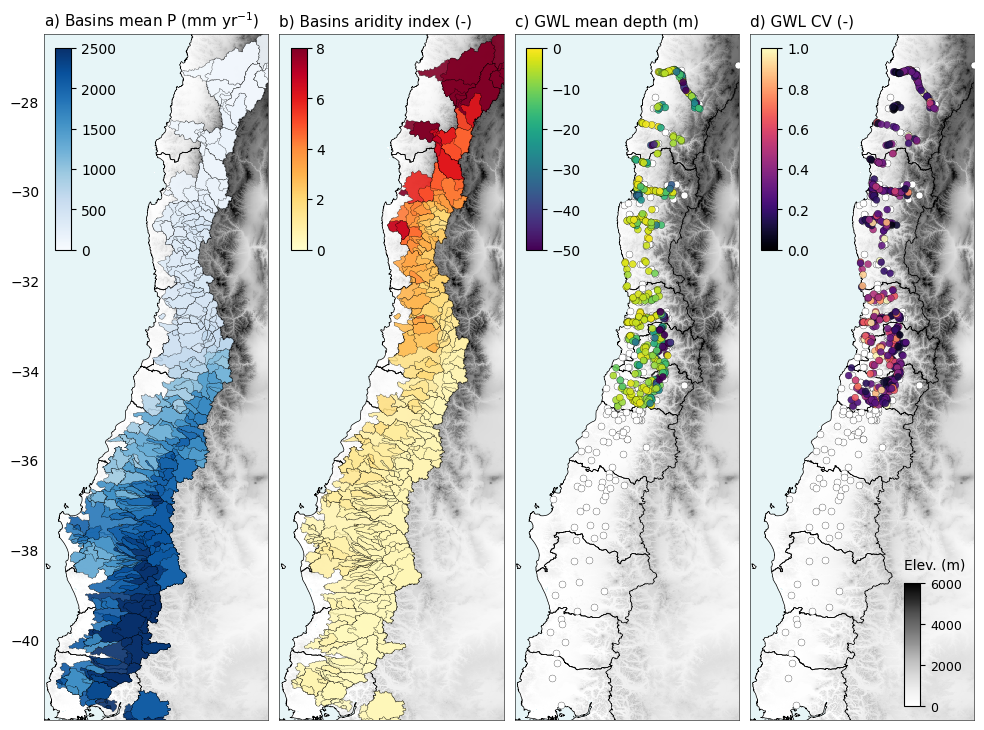

In [2]:
# === Load data ===
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Basin data
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
q_attrib['p_mean_cr2met_1979_2010'] = q_attrib['p_mean_cr2met_1979_2010'] * 365
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

# Groundwater data
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

# DEM data
dem_min_lon, dem_max_lon = -74, -69
dem_min_lat, dem_max_lat = -41.8, -26.5

def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

etopo_ds = xr.open_dataset('../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc')
elevation_etopo = etopo_ds['z']
elevation_etopo = slice_dim(elevation_etopo, 'lon', dem_min_lon, dem_max_lon)
elevation_etopo = slice_dim(elevation_etopo, 'lat', dem_min_lat, dem_max_lat)


# Regions
regions_gdf = gpd.read_file('../data/other/cl_regiones_geo/cl_regiones_geo.shp')

# === Prepare data for maps ===
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)

q_map = q_gpkg.merge(
    q_attrib[['gauge_id', 'area_km2','p_mean_cr2met_1979_2010', 'aridity_cr2met_1979_2010']],
    on='gauge_id',
    how='left'
)
q_map = q_map.sort_values(by='area_km2', ascending=False)

gw_map = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)

# === Figure ===
fig, axes = plt.subplots(1, 4, figsize=(12, 10))
fig.subplots_adjust(wspace=0.05)

titles = [
    'a) Basins mean P (mm yr$^{-1}$)',
    'b) Basins aridity index (-)',
    'c) GWL mean depth (m)',
    'd) GWL CV (-)'
]

cols = [
    'p_mean_cr2met_1979_2010',
    'aridity_cr2met_1979_2010',
    'cr2sub_clean_mean_gwl',
    'cr2sub_clean_cv_gwl'
]

cmaps = [plt.cm.Blues, plt.cm.YlOrRd, plt.cm.viridis, plt.cm.magma]
norms = [
    plt.Normalize(0, 2500),
    plt.Normalize(0, 8),
    plt.Normalize(-50, 0),
    plt.Normalize(0, 1)
]

data_list = [q_map, q_map, gw_map, gw_map]
types = ['polygon', 'polygon', 'point', 'point']

# Elevation background
lon_vals = elevation_etopo['lon'].values
lat_vals = elevation_etopo['lat'].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

elev = elevation_etopo.values
elev_land = np.where(elev <= 0, np.nan, elev)
elevation_norm = plt.Normalize(0, 6000)

for i, ax in enumerate(axes):
    # DEM background
    ax.pcolormesh(
        lon_grid, lat_grid, elev_land,
        shading='auto',
        cmap=plt.cm.Greys,
        norm=elevation_norm
    )

    # Regions
    regions_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.5)

    # Ocean background
    ax.set_facecolor(to_rgba('powderblue', 0.3))

    # Plot data
    if types[i] == 'polygon':
        data_list[i].plot(
            ax=ax,
            column=cols[i],
            cmap=cmaps[i],
            norm=norms[i],
            linewidth=0.2,
            edgecolor='black',
            alpha=0.9
        )
    else:
        valid = data_list[i].dropna(subset=[cols[i]])
        missing = data_list[i][data_list[i][cols[i]].isna()]

        if len(valid) > 0:
            valid.plot(
                ax=ax,
                column=cols[i],
                cmap=cmaps[i],
                norm=norms[i],
                markersize=25,
                edgecolor='black',
                linewidth=0.2,
                alpha=0.9,
                zorder=10
            )

        if len(missing) > 0:
            missing.plot(
                ax=ax,
                color='white',
                edgecolor='black',
                markersize=25,
                linewidth=0.2,
                zorder=5
            )

    # Panel format
    ax.set_title(titles[i], fontsize=11, loc='left')
    ax.set_xlim(dem_min_lon, dem_max_lon)
    ax.set_ylim(dem_min_lat, dem_max_lat)
    ax.set_aspect('equal')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.tick_params(axis='both', length=0)

    if i > 0:
        ax.set_yticklabels([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    # Colorbar
    sm = plt.cm.ScalarMappable(norm=norms[i], cmap=cmaps[i])
    sm.set_array([])
    cax = inset_axes(ax, width="8%", height="35%", loc='upper left',
                     bbox_to_anchor=(0.05, 0.14, .9, .84),
                     bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=10)

# DEM colorbar
sm_elev = plt.cm.ScalarMappable(norm=elevation_norm, cmap=plt.cm.Greys)
sm_elev.set_array([])
cax_elev = inset_axes(axes[2], width="8%", height="20%", loc='lower right',
                      bbox_to_anchor=(0.91, 0.02, .9, .9),
                      bbox_transform=axes[2].transAxes, borderpad=0)
cbar_elev = plt.colorbar(sm_elev, cax=cax_elev)
cbar_elev.ax.set_title('Elev. (m)', fontsize=10, loc='left', pad=10)
cbar_elev.ax.tick_params(labelsize=9)

plt.savefig('Fig1_study_area.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig.2 ms - Data availabiliyy

/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_37551/1686025864.py:82: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(regions_gw, axis=1).mean()
/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_37551/1686025864.py:95: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(regions_q, axis=1).mean()


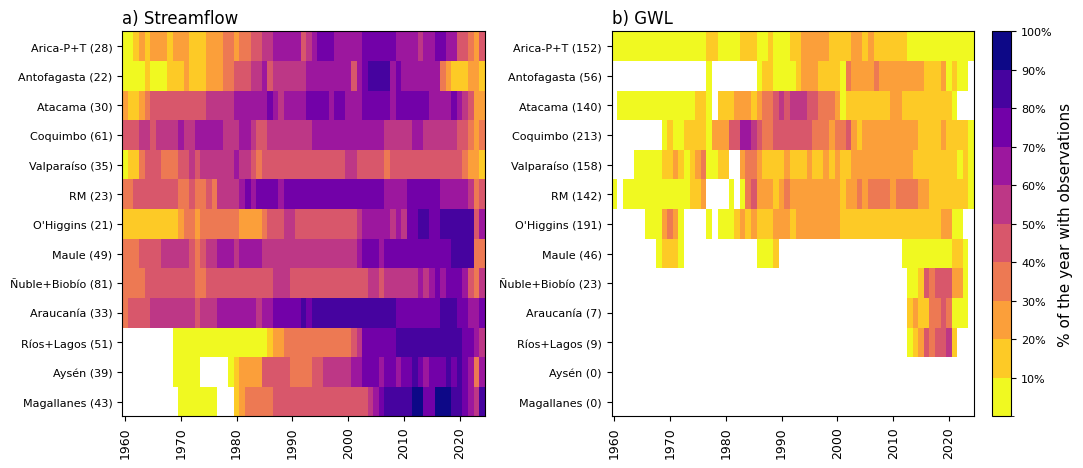

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.colors import BoundaryNorm

# -------------------- Paths --------------------
data_dir = '/Users/cag/Dropbox/0_Research/0_githubs/ms_recovery/data'
ms_data_dir = f'{data_dir}/cr2sub'
camels_dir  = f'{data_dir}/camels'

# -------------------- 1) Cargar series (date index, sin columnas duplicadas) --------------------
gw_df = pd.read_csv(f'{ms_data_dir}/cr2sub_v1.1_gwl_mon.csv', parse_dates=['date']).set_index('date')
q_df  = pd.read_csv(f'{camels_dir}/camels_q_mm.csv', parse_dates=['date']).set_index('date')
gw_df = gw_df.loc[:, ~gw_df.columns.duplicated()]
q_df  = q_df.loc[:,  ~q_df.columns.duplicated()]


# -------------------- Región: orden + códigos --------------------
REGION_NAME_ORDER = [
    'Arica-P+T','Antofagasta','Atacama','Coquimbo','Valparaíso','RM',"O'Higgins",
    'Maule','Ñuble+Biobío','Araucanía','Ríos+Lagos','Aysén','Magallanes'
]
REGION_SORT_ORDER = {name: i for i, name in enumerate(REGION_NAME_ORDER)}

REGION_CODE_TO_LABEL = {
    1:'Arica-P+T', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Ñuble+Biobío', 9:'Araucanía', 10:'Ríos+Lagos',
    11:'Aysén', 12:'Magallanes', 13:'RM'
}

def extract_region(code):
    """Dado un código/colname (tipo DGA), infiere región según tu regla."""
    s = str(code)
    digits = ''.join(ch for ch in s if ch.isdigit())
    if len(digits) >= 8: #e.g., 103400012
        prefix = int(digits[:2])
    elif digits and digits[0] == '5':
        prefix = int(digits[:2])
    else:
        prefix = int(digits[0]) # 1,2,3,4 + 6,7,8,9
        
    if 51 <= prefix <= 56:
        return 'Valparaíso'
    if prefix in (57, 58):
        return 'RM'
    return REGION_CODE_TO_LABEL.get(prefix, str(prefix))

# -------------------- 2) conteos por región --------------------
gw_region_map = {}
for c in gw_df.columns:
    try:
        gw_region_map[c] = extract_region(c)
    except Exception:
        pass

q_region_map = {}
for c in q_df.columns:
    try:
        q_region_map[c] = extract_region(c)
    except Exception:
        pass

gw_counts = Counter(gw_region_map.values())
q_counts  = Counter(q_region_map.values())

# Orden final de regiones (unión Q + GW, en tu orden predefinido)
regions_all = sorted(set(gw_counts.keys()).union(q_counts.keys()),
                     key=lambda r: REGION_SORT_ORDER.get(r, 1e9))


# disponibilidad mensual (1 = dato, 0 = missing) → promedio anual
min_year, max_year = 1960, 2024
years_full = np.arange(min_year, max_year + 1)

# -------- Groundwater --------
regions_gw = pd.Series({c: extract_region(c) for c in gw_df.columns})

gw_cov = (
    gw_df.notna().astype(float)
        .resample('YE').mean()
        .groupby(regions_gw, axis=1).mean()
)

gw_cov.index = gw_cov.index.year
gw_cov = gw_cov.reindex(years_full).reindex(columns=regions_all)


# -------- Streamflow --------
regions_q = pd.Series({c: extract_region(c) for c in q_df.columns})

q_cov = (
    q_df.notna().astype(float)
        .resample('YE').mean()
        .groupby(regions_q, axis=1).mean()
)

q_cov.index = q_cov.index.year
q_cov = q_cov.reindex(years_full).reindex(columns=regions_all)


# -------- Matrices para pcolormesh --------
q_mat, years_q   = q_cov.values.T, q_cov.index.values
gw_mat, years_gw = gw_cov.values.T, gw_cov.index.values


# -------------------- 4) Plot (dos paneles) --------------------
bins = np.linspace(0, 1, 11)                          # 0–100% en 10 bins
tick_pos = bins[1:]
tick_lab = [f"{int(b*100)}%" for b in tick_pos]
cmap = plt.get_cmap('plasma_r', len(bins)-1).copy()
cmap.set_bad(color='white')
norm = BoundaryNorm(bins, cmap.N)

def labels_with_counts(regions, counts):
    return [f"{r} ({counts.get(r,0)})" for r in regions]

fig, (ax_q, ax_gw) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.subplots_adjust(wspace=0.35, right=0.88)

for ax, mat, years, title, counts in [
    (ax_q,  q_mat,  years_q,  "a) Streamflow", q_counts),
    (ax_gw, gw_mat, years_gw, "b) GWL",       gw_counts),
]:
    if mat.size == 0 or years.size == 0:
        ax.text(0.5, 0.5, "Sin datos", ha='center', va='center')
        ax.axis('off')
        continue

    # Enmascarar NaN y ceros (si 0 significa “sin dato” en tu caso)
    masked = np.ma.masked_where(~np.isfinite(mat) | (mat <= 0), mat)

    # Bordes para pcolormesh (años en x, regiones en y)
    x_edges = np.linspace(years.min()-0.5, years.max()+0.5, len(years)+1)
    y_edges = np.arange(-0.5, len(regions_all)+0.5, 1)
    X, Y = np.meshgrid(x_edges, y_edges)

    im = ax.pcolormesh(X, Y, masked, cmap=cmap, norm=norm, shading='auto',
                       edgecolors='lightgray', linewidth=0.001)

    ax.set_title(title, loc='left')
    ax.set_yticks(np.arange(len(regions_all)))
    ax.set_yticklabels(labels_with_counts(regions_all, counts), fontsize=8)
    ax.set_ylim(len(regions_all)-0.5, -0.5)

    # ticks cada 10 años
    start = (years.min()//10)*10
    end   = (years.max()//10)*10
    decades = np.arange(start, end+10, 10)
    decades = decades[(decades >= years.min()) & (decades <= years.max())]
    ax.set_xticks(decades)
    ax.set_xticklabels(decades, rotation=90, ha='center', fontsize=9)

# colorbar común
cb = fig.colorbar(im, ax=[ax_q, ax_gw], orientation='vertical',
                  pad=0.02, fraction=0.04, ticks=tick_pos)
cb.ax.set_yticklabels(tick_lab)
cb.set_label('% of the year with observations', fontsize=11)
cb.ax.tick_params(labelsize=8)

plt.savefig('Fig2_data_availability.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig.4 ms - P/Q/GWL seasonality

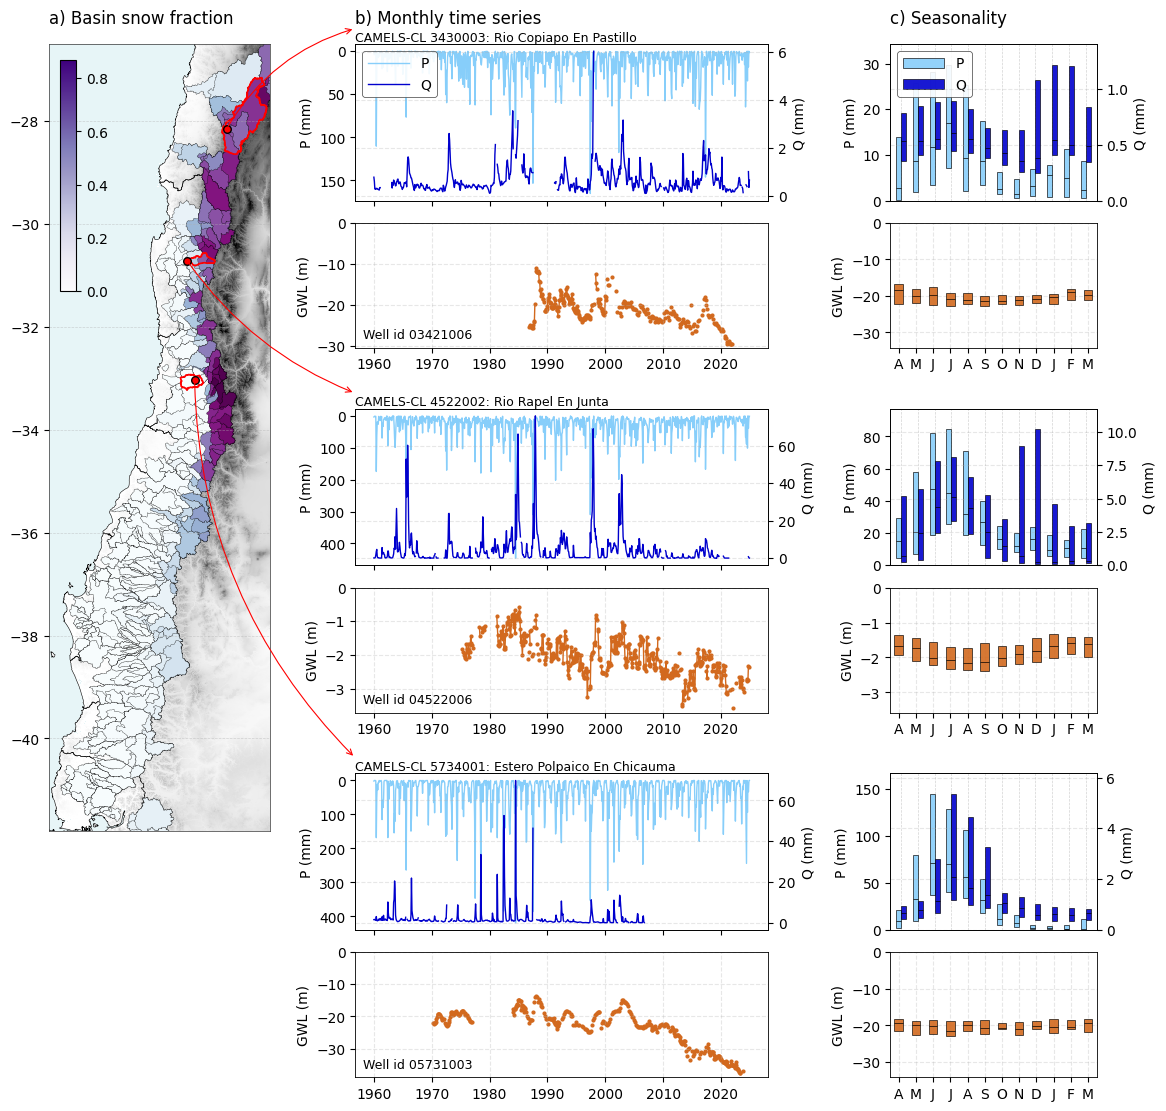

In [101]:
import matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.colors import to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 0) Configuración
# =========================
# well_codes = ['03421006', '05731003', '06015017']
# well_codes = ['03421006', '04550006', '06011014']
well_codes = ['03421006', '04522006', '05731003']
months_order = list(range(4, 13)) + list(range(1, 4))                 # Abr..Dic + Ene..Mar
month_labels = ['A','M','J','J','A','S','O','N','D','J','F','M']       # para eje x
boxplot_cutoff = pd.Timestamp('2010-01-01')                            # usar datos < 2010
n_wells = len(well_codes)

# col_p  = 'blue'
# col_q  = 'forestgreen'
# col_gw = 'orangered'

col_p  = 'lightskyblue'
col_q  = 'mediumblue'
col_gw = 'chocolate'
# col_q = 'steelblue'
# col_gw = 'indianred'

date_range = pd.date_range('1960-01-01', '2024-12-01', freq='MS')      # mensual

# =========================
# 1) Cargar datos (series + atributos + shapes)
# =========================
data_dir = Path('../data')
gwl = pd.read_csv(data_dir/'cr2sub/cr2sub_v1.1_gwl_mon_clean.csv', parse_dates=['date']).set_index('date'); gwl.columns=gwl.columns.astype(str)
pr  = pd.read_csv(data_dir/'camels/camels_pr_mm.csv', parse_dates=['date']).set_index('date'); pr.columns=pr.columns.astype(str)
q   = pd.read_csv(data_dir/'camels/camels_q_mm.csv', parse_dates=['date']).set_index('date'); q.columns=q.columns.astype(str)
attr = pd.read_csv(data_dir/'cr2sub/cr2sub_v1.1_attributes.csv')

attr['cr2sub_id']  = attr['cr2sub_id'].astype(int).astype(str)
attr['cr2sub_in_basin_camels'] = attr['cr2sub_in_basin_camels'].astype(float).astype('Int64').astype(str)

camels_shapes = gpd.read_file(data_dir/'camels/CAMELScl_boundaries_epsg4326.gpkg')
camels_shapes['gauge_id'] = camels_shapes['gauge_id'].astype(str)

camels_attrs = pd.read_csv(data_dir/'camels/catchment_attributes.csv')[
    ['gauge_id', 'gauge_name', 'frac_snow_cr2met_1979_2010', 'area_km2']
]
camels_attrs['gauge_id'] = camels_attrs['gauge_id'].astype(str)

map_gdf = camels_shapes.merge(camels_attrs, on='gauge_id', how='left')
map_gdf = map_gdf.sort_values(by='area_km2', ascending=False)

regions = gpd.read_file(data_dir / 'other' / 'cl_regiones_geo' / 'cl_regiones_geo.shp')
well_points = gpd.GeoDataFrame(
    attr,
    geometry=gpd.points_from_xy(attr['cr2sub_lon'], attr['cr2sub_lat']),
    crs='EPSG:4326'
)

# DEM para fondo
dem = xr.open_dataset(data_dir / 'other' / 'ETOPO_2022_v1_30s_N90W180_bed.nc')['z']
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
dem = dem.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))
dem_masked = np.ma.masked_less_equal(dem.values, 0)
elevation_vmin = 0
elevation_vmax = 6000
elevation_cmap = plt.cm.Greys
elevation_norm = plt.Normalize(vmin=elevation_vmin, vmax=elevation_vmax)


# --- Helpers ---
def norm_code(code):
    digits = ''.join(ch for ch in str(code) if ch.isdigit())
    stripped = digits.lstrip('0')
    return stripped or digits or str(code)

well_lookup = {code: norm_code(code) for code in well_codes}
date_range = pd.date_range('1960-01-01', '2024-12-31', freq='MS')


panel_labels_ts = ['b) Monthly time series']          # títulos para las series P/Q
panel_labels_box = ['c) Seasonality'] 

fig = plt.figure(figsize=(11, 11), constrained_layout=True)
outer_gs = gridspec.GridSpec(n_wells * 2 + 1, 2, width_ratios=[1.6, 6], figure=fig)

map_rows = 7  # 
ax_map = fig.add_subplot(outer_gs[:map_rows, 0], frameon=True)
ax_map.set_facecolor(to_rgba('powderblue', 0.3))
ax_map.set_title('a) Snow fraction map', loc='left')

lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)  # leave oceans/flat areas blank

ax_map.pcolormesh(lon_grid, lat_grid, dem_masked, shading='auto', cmap=elevation_cmap, norm=elevation_norm)
regions.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.4)
  
snow_column = 'frac_snow_cr2met_1979_2010'
snow_values = map_gdf[snow_column]
snow_norm = plt.Normalize(vmin=snow_values.min(), vmax=snow_values.max())

map_gdf.plot(
    ax=ax_map,
    column=snow_column,
    cmap='BuPu',
    linewidth=0.2,
    edgecolor='black'
)

ax_map.yaxis.set_ticks_position('left')
ax_map.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
ax_map.tick_params(axis='y', right=False, labelright=False)
ax_map.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

for spine in ax_map.spines.values():
    spine.set_linewidth(0.5)              # ajusta el valor (0.5, 0.3, etc.)
    spine.set_edgecolor('0.2')            # opcional: color más suave


sm = plt.cm.ScalarMappable(norm=snow_norm, cmap='Purples')
sm.set_array([])
cax = inset_axes(
    ax_map, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.14, .9, .84),
    bbox_transform=ax_map.transAxes, borderpad=0
)
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=10)

ax_map.set_xlim(min_lon, max_lon)
ax_map.set_ylim(min_lat, max_lat)
ax_map.set_title('a) Basin snow fraction', loc='left', pad = 15)
ax_map.set_anchor('NW')

height_ratios = []
for _ in range(n_wells):
    height_ratios.extend([1, 0.8, 0.1])
height_ratios = height_ratios[:-1]

inner_gs = gridspec.GridSpecFromSubplotSpec(
    len(height_ratios), 2,
    subplot_spec=outer_gs[:, 1],
    height_ratios=height_ratios,
    width_ratios=[4, 2],
    hspace=0.03,
    wspace=0.03
)

used_gauges = []
used_wells = []

def monthly_arrays(series):
    clean = series[series.index < boxplot_cutoff].dropna()
    grouped = clean.groupby(clean.index.month)
    monthly_data = [grouped.get_group(m).values if m in grouped.groups else [] for m in months_order]

    monthly_p75 = []
    monthly_p25 = []
    for arr in monthly_data:
        if len(arr):
            monthly_p75.append(np.nanpercentile(arr, 75))
            monthly_p25.append(np.nanpercentile(arr, 25))
        else:
            monthly_p75.append(np.nan)
            monthly_p25.append(np.nan)

    valid_p75 = [v for v in monthly_p75 if not np.isnan(v)]
    valid_p25 = [v for v in monthly_p25 if not np.isnan(v)]
    max_p75 = max(valid_p75) if valid_p75 else np.nan
    min_p25 = min(valid_p25) if valid_p25 else np.nan

    return monthly_data, max_p75, min_p25


ts_axes = []

for idx, raw_code in enumerate(well_codes):
    # 2) Dentro del loop:
    label_idx = 1 + idx   # porque para cada pozo tienes 4 paneles (P/Q TS, GW TS, P/Q boxes, GW boxes)

    code = well_lookup[raw_code]
    match = attr[attr['cr2sub_id'] == code]
    if match.empty:
        continue
    gauge_id = str(int(match['cr2sub_in_basin_camels'].iloc[0]))
    basin_name = camels_attrs[camels_attrs['gauge_id'] == gauge_id]['gauge_name'].iloc[0]
    if code not in gwl.columns or gauge_id not in pr.columns or gauge_id not in q.columns:
        continue

    gwl_series = gwl[code].reindex(date_range)
    pr_series = pr[gauge_id].reindex(date_range)
    q_series = q[gauge_id].reindex(date_range)

    row_ts = idx * 3
    row_box = row_ts + 1

    ax_ts = fig.add_subplot(inner_gs[row_ts, 0])
    ts_axes.append(ax_ts)
    
    ax_ts.plot(pr_series.index, pr_series, color=col_p, lw=1)
    ax_ts.invert_yaxis()
    ax_ts.set_ylabel('P (mm)')
    ax_ts.tick_params(axis='x', labelbottom=False)
    # ax_ts.set_title(f"{panel_labels_ts[idx]}) CAMELS-CL {gauge_id}: {basin_name}", loc='left')   
    if idx == 0:    
        ax_ts.set_title("b) Monthly time series", loc='left', pad=15)   
    
    ax_ts.text(
        0.0, 1,
        f"CAMELS-CL {gauge_id}: {basin_name}",
        transform=ax_ts.transAxes,
        ha='left',
        va='bottom',
        fontsize=9
    )
             
    ax_q = ax_ts.twinx()
    ax_q.plot(q_series.index, q_series, color=col_q, lw=1)
    ax_q.set_ylabel('Q (mm)')
    ax_q.grid(True, linestyle='--', alpha=0.3)
    

    if idx == 0:
        legend_handles = [
            ax_ts.lines[0],
            ax_q.lines[0],
            # ax_gw.lines[0],
        ]
        legend_labels = ['P', 'Q']
        legend = ax_ts.legend(
            legend_handles,
            legend_labels,
            loc='upper left',
            frameon=True,
            fontsize=10,
            handlelength=3,
        )
        legend.get_frame().set_linewidth(0.6)   # grosor fino
        legend.get_frame().set_edgecolor('0.3') # color suave opcional
        legend.get_frame().set_alpha(0.9)       # opcional   
      
  
    ax_gw = fig.add_subplot(inner_gs[row_box, 0], sharex=ax_ts)
    ax_gw.plot(gwl_series.index, gwl_series, color=col_gw, lw=1)
    ax_gw.scatter(gwl_series.index, gwl_series, color=col_gw, s=4)
    ax_gw.set_ylabel('GWL (m)')
    ax_gw.set_ylim(top=0)
    ax_gw.grid(True, linestyle='--', alpha=0.3)
    ax_gw.tick_params(axis='x', labelbottom=True)
     
    # anotación dentro del panel (abajo izquierda)
    ax_gw.text(0.02, 0.05,f"Well id {raw_code}",transform=ax_gw.transAxes,ha='left',va='bottom',fontsize=9)

    # calculos para boxplots
    pr_data, pr_p75, pr_p25 = monthly_arrays(pr_series)
    q_data, q_p75, q_p25 = monthly_arrays(q_series)
    gw_data, gw_p75, gw_p25 = monthly_arrays(gwl_series)

    ylim_max1 = pr_p75 * 1.15 if not np.isnan(pr_p75) else 1
    ylim_max2 = q_p75 * 1.15 if not np.isnan(q_p75) else 1
    ylim_max3 = gw_p25 * 1.5 if not np.isnan(gw_p25) else -1

    ax_box = fig.add_subplot(inner_gs[row_ts, 1])
    bp_p = ax_box.boxplot(
        pr_data,
        positions=[x - 0.15 for x in range(1, 13)],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_p, alpha=0.9, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax_box.set_ylabel('P (mm)')
    # ax_box.set_title('Seasonality', loc='left')
    ax_box.set_ylim(0, ylim_max1)
    for month in range(1, 13):
        ax_box.axvline(month, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

    # ax_box.set_title(f'{panel_labels[label_idx+2]}) Seasonality', loc='left')
    if idx == 0:  
        ax_box.set_title("c) Seasonality", loc='left', pad = 15)
    
    ax_box_q = ax_box.twinx()
    bp_q = ax_box_q.boxplot(
        q_data,
        positions=[x + 0.15 for x in range(1, 13)],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_q, alpha=0.9, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box_q.set_ylabel('Q (mm)')
    ax_box_q.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax_box_q.set_ylim(0, ylim_max2)
       
    if idx == 0:
        legend_handles = [
            bp_p['boxes'][0],
            bp_q['boxes'][0],
            # ax_gw.lines[0],
        ]
        legend_labels = ['P', 'Q']
        legend = ax_box.legend(
            legend_handles,
            legend_labels,
            loc='upper left',
            frameon=True,
            fontsize=10,
            handlelength=3,
        )
        legend.get_frame().set_linewidth(0.6)   # grosor fino
        legend.get_frame().set_edgecolor('0.3') # color suave opcional
        legend.get_frame().set_alpha(0.9)       # opcional   
        
        
    ax_box_gw = fig.add_subplot(inner_gs[row_box, 1])
    ax_box_gw.boxplot(
        gw_data,
        positions=range(1, 13),
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_gw, alpha=0.9, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box_gw.set_xticks(range(1, 13))
    ax_box_gw.set_xticklabels(month_labels)
    ax_box_gw.set_ylabel('GWL (m)')
    ax_box_gw.grid(True, linestyle='--', alpha=0.3)
    ax_box_gw.set_ylim(ylim_max3, 0)
    # ax_box_gw.set_title(f'{panel_labels[label_idx+3]}) GW seasonality', loc='left')
    
    for ax in [ax_ts, ax_q, ax_gw, ax_box, ax_box_q, ax_box_gw]:
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
        
       
# polígonos rojos para destacar basins y pozos seleccionados
    used_gauges.append(gauge_id)
    used_wells.append(code)
    
selected_basins = map_gdf[map_gdf['gauge_id'].isin(used_gauges)]
if not selected_basins.empty:
    selected_basins.plot(ax=ax_map, facecolor='none', edgecolor='red', linewidth=1.2)
selected_wells = well_points[well_points['cr2sub_id'].isin(used_wells)]
if not selected_wells.empty:
    selected_wells.plot(ax=ax_map, color='red', markersize=30, edgecolor='black')

# === Draw arrows from basin centroid (map) to time series title ===
for i, cod in enumerate(well_codes):
    match = attr[attr['cr2sub_id'] == norm_code(cod)]
    if match.empty or i >= len(ts_axes):
        continue
    well_geom = well_points[well_points['cr2sub_id'] == norm_code(cod)].geometry.values[0]

    if i == 0:
        curve_rad = -0.2  # curve downward
    if i == 1:
        curve_rad = 0.15  # curve downward
    if i == 2:
        curve_rad = 0.2   # keep upward
        
    ax_map.annotate(
        '',
        xy=(0, 1.1), xycoords=ts_axes[i].transAxes,
        xytext=(well_geom.x, well_geom.y), textcoords='data',
        arrowprops=dict(
            arrowstyle='->',
            lw=.8,
            color='red',
            connectionstyle=f"arc3,rad={curve_rad}",
        ),
        annotation_clip=False,
    )
    
# Manually adjust layout to prevent map from being pushed off-screen
ax_map.set_position([
    ax_map.get_position().x0-0.05,
    ax_map.get_position().y0,
    ax_map.get_position().width,
    ax_map.get_position().height
])


        
plt.savefig('Fig4_P_Q_GW_ts_seasonality.png', dpi=600, bbox_inches='tight')
plt.show()


### Fig.5 ms - R2 LR models 2-side map + ts

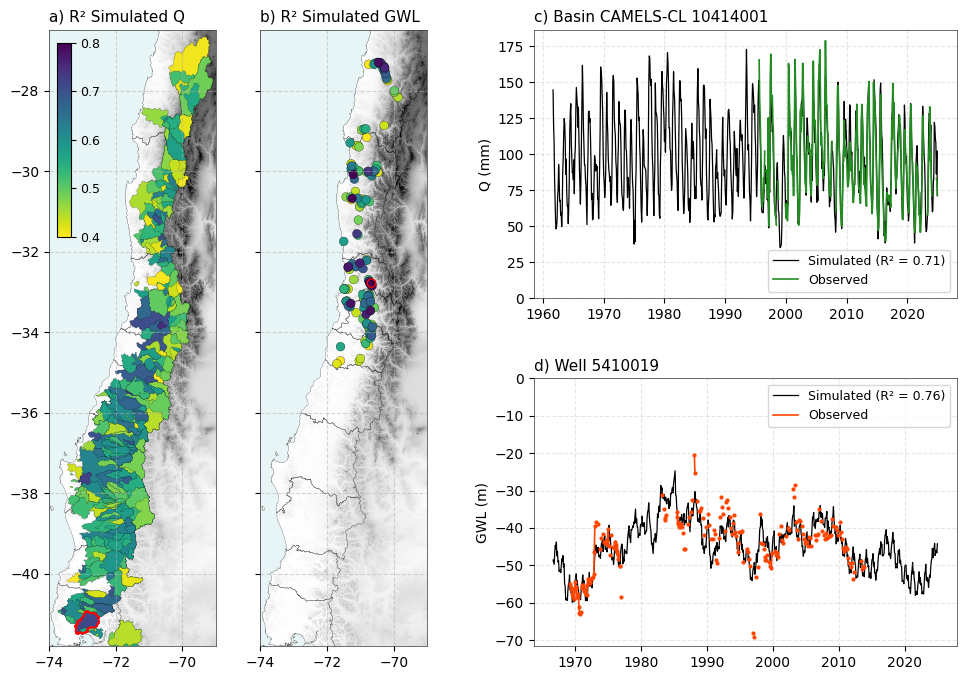

In [77]:
######### MAP R2 performance LR models + monthly time series #########

# === load data ===
q_r2_df = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_r2_df = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv').rename(columns={'cr2sub_id': 'well_id'})
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
path_netcdf = '../data/other/elevation_srtm_v4.1_Chile_2000_1200m_epsg4326.nc'

# simulaciones históricas
q_sim = pd.read_csv('../analysis/5_recovery/csv/q_sim_hist.csv', parse_dates=['date']).set_index('date')
gw_sim = pd.read_csv('../analysis/5_recovery/csv/gw_sim_hist.csv', parse_dates=['date']).set_index('date')
q_sim.columns = q_sim.columns.astype(str)
gw_sim.columns = gw_sim.columns.astype(str)

# === Load the GeoPackage files ===
gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

# asegurar mismo tipo de IDs antes del merge
q_r2_df['gauge_id'] = q_r2_df['gauge_id'].astype(str)
gw_r2_df['well_id'] = gw_r2_df['well_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)
gwl_gpkg['well_id'] = gwl_gpkg['well_id'].astype(str)

# merge de r2 al geodataframe
q_gpkg = q_gpkg.merge(
    q_r2_df[['gauge_id', 'max_r2_selected_configs']],
    on='gauge_id',
    how='left'
)

gwl_gpkg = gwl_gpkg.merge(
    gw_r2_df[['well_id', 'max_r2_selected_configs']],
    on='well_id',
    how='left'
)

# observed series :
gwl = pd.read_csv('../data/cr2sub/cr2sub_v1.1_gwl_mon_clean.csv', parse_dates=['date']).set_index('date')
q   = pd.read_csv('../data/camels/camels_q_mm.csv', parse_dates=['date']).set_index('date')
gwl.columns = gwl.columns.astype(str)
q.columns = q.columns.astype(str)

# DEM data
dem_min_lon, dem_max_lon = -74, -69
dem_min_lat, dem_max_lat = -41.8, -26.5

def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

etopo_ds = xr.open_dataset('../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc')
elevation_etopo = etopo_ds['z']
elevation_etopo = slice_dim(elevation_etopo, 'lon', dem_min_lon, dem_max_lon)
elevation_etopo = slice_dim(elevation_etopo, 'lat', dem_min_lat, dem_max_lat)

# Regions
regions_gdf = gpd.read_file('../data/other/cl_regiones_geo/cl_regiones_geo.shp')


# === FIGURE ===

col_p  = 'blue'
col_q  = 'forestgreen'
col_gw = 'orangered'
# col_q = 'steelblue'
# col_gw = 'indianred'


gauge_id_plot = '10414001'
# well_id_plot = '5735008'
well_id_plot = '5410019'

# common monthly date range
date_range = pd.date_range('1960-01-01', '2024-12-01', freq='MS')

# observed + simulated series
q_obs_ser = q[gauge_id_plot].reindex(date_range) if gauge_id_plot in q.columns else pd.Series(index=date_range, dtype=float)
q_sim_ser = q_sim[gauge_id_plot].reindex(date_range) if gauge_id_plot in q_sim.columns else pd.Series(index=date_range, dtype=float)

gwl_obs_ser = gwl[well_id_plot].reindex(date_range) if well_id_plot in gwl.columns else pd.Series(index=date_range, dtype=float)
gwl_sim_ser = gw_sim[well_id_plot].reindex(date_range) if well_id_plot in gw_sim.columns else pd.Series(index=date_range, dtype=float)

# === continuous color scale for the map ===
cmap = plt.cm.viridis_r
norm = plt.Normalize(vmin=0.4, vmax=0.8)

q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='max_r2_selected_configs', ascending=True)

# === map extent ===
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
gwl_gpkg = gwl_gpkg[(gwl_gpkg.geometry.y <= max_lat) & (gwl_gpkg.geometry.y >= min_lat)]
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]

# DEM
dem = elevation_etopo
dem = dem.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))
lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)

elevation_cmap = plt.cm.Greys
elevation_norm = plt.Normalize(vmin=0, vmax=6000)

# === figure and compact layout ===
fig = plt.figure(figsize=(12, 8), constrained_layout=False)

outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], figure=fig)
maps_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], wspace=0.0)
ts_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1], hspace=0.3)

ax1 = fig.add_subplot(maps_gs[0, 0])
ax2 = fig.add_subplot(maps_gs[0, 1])

ax3 = fig.add_subplot(ts_gs[0, 0])
ax4 = fig.add_subplot(ts_gs[1, 0])

size_pt = 40

# === map backgrounds ===
ax1.set_facecolor(to_rgba('powderblue', 0.3))
ax2.set_facecolor(to_rgba('powderblue', 0.3))

ax1.pcolormesh(lon_grid, lat_grid, dem_masked, cmap=elevation_cmap, norm=elevation_norm, shading='auto')
ax2.pcolormesh(lon_grid, lat_grid, dem_masked, cmap=elevation_cmap, norm=elevation_norm, shading='auto')

regions_gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)
regions_gdf.plot(ax=ax2, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

# usar el R² real, no bin_idx
q_gpkg.plot(
    ax=ax1,
    column='max_r2_selected_configs',
    cmap=cmap,
    norm=norm,
    alpha=1,
    edgecolor='black',
    linewidth=0.1,
)

gwl_gpkg.plot(
    ax=ax2,
    column='max_r2_selected_configs',
    cmap=cmap,
    norm=norm,
    markersize=size_pt,
    alpha=1,
    edgecolor='black',
    linewidth=0.2,
)

ax1.set_title('a) R² Simulated Q', fontsize=11, loc='left')
ax2.set_title('b) R² Simulated GWL', fontsize=11, loc='left')

ax1.set_xlim(min_lon, max_lon)
ax1.set_ylim(min_lat, max_lat)

ax2.set_xlim(min_lon, max_lon)
ax2.set_ylim(min_lat, max_lat)
ax2.set_yticklabels([])

# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax_cbar = inset_axes(
    ax1, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .9),
    bbox_transform=ax1.transAxes, borderpad=0
)
cbar = plt.colorbar(sm, cax=cax_cbar, orientation='vertical')
# cbar.ax.set_title("R²", fontsize=10, loc='left', pad=10)
cbar.ax.tick_params(labelsize=8)
# cbar.ax.set_yticks(bins)
# cbar.ax.set_yticklabels([f"{b:.1f}" for b in bins])

cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(np.arange(0.4, 0.81, 0.1))

# === highlight selected basin/well on maps ===
# === get R² values for selected basin and well ===
q_r2_text = np.nan
gw_r2_text = np.nan
sel_basin = q_gpkg[q_gpkg['gauge_id'] == gauge_id_plot]
if not sel_basin.empty:
    sel_basin.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=1.2)
    q_r2_text = sel_basin['max_r2_selected_configs'].iloc[0]

sel_well = gwl_gpkg[gwl_gpkg['well_id'] == well_id_plot]
if not sel_well.empty:
    sel_well.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=.9)
    gw_r2_text = sel_well['max_r2_selected_configs'].iloc[0]
  
    
aspect_val = 1 / np.cos(np.deg2rad((min_lat + max_lat) / 2))
ax1.set_aspect(aspect_val, adjustable='box')
ax2.set_aspect(aspect_val, adjustable='box')

# === right panel: monthly streamflow time series ===
ax3.plot(q_sim_ser.index, q_sim_ser, color='black', lw=.9, ls='-', label=f"Simulated (R² = {q_r2_text:.2f})")
ax3.plot(q_obs_ser.index, q_obs_ser, color=col_q, lw=1.2, label='Observed')
ax3.set_ylabel('Q (mm)')
ax3.set_title(f'c) Basin CAMELS-CL {gauge_id_plot}', loc='left', fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=True, fontsize=9, loc='lower right')


# === right panel: monthly groundwater time series ===
ax4.plot(gwl_sim_ser.index, gwl_sim_ser, color='black', lw=.9, ls='-', label=f"Simulated (R² = {gw_r2_text:.2f})", zorder =0)
ax4.plot(gwl_obs_ser.index, gwl_obs_ser, color=col_gw, lw=1.2, label='Observed')
ax4.scatter(gwl_obs_ser.index, gwl_obs_ser, color=col_gw, s=4)
ax4.set_ylabel('GWL (m)')
ax4.set_title(f'd) Well {well_id_plot}', loc='left', fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.3)
ax4.set_ylim(top=0)
ax4.legend(frameon=True, fontsize=9, loc='upper right')

# thinner spines
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_edgecolor('0.2')

for ax in [ax1, ax2]:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Fig5_r2_LR_models_with_ts.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig.6 ms - Maps hydro memory

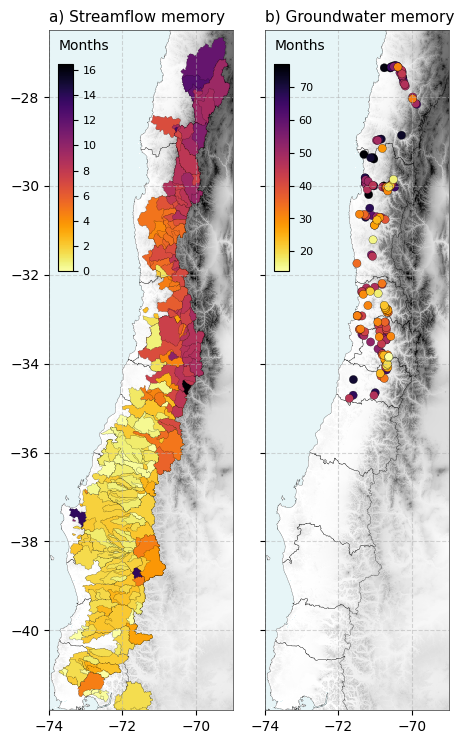

In [102]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
import matplotlib.cm as cm

# =========================
# 1) LOAD DATA
# =========================

# Streamflow
q_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

q_memory_data['gauge_id'] = q_memory_data['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)

# Groundwater
gw_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv2/gw_memory.csv')
gw_memory_data = gw_memory_data.rename(columns={'well_id': 'cr2sub_id'})

gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)
gw_memory_data['cr2sub_id'] = gw_memory_data['cr2sub_id'].astype(str)

gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
gwl_gpkg['cr2sub_id'] = gwl_gpkg['cr2sub_id'].astype(str)

# Merge memory with geometries
q_gpkg = q_gpkg.merge(q_memory_data, on='gauge_id', how='left')
gwl_gpkg = gwl_gpkg.merge(gw_memory_data, on='cr2sub_id', how='left')

# Regions
regions_gdf = gpd.read_file('../data/other/cl_regiones_geo/cl_regiones_geo.shp')

# DEM
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

etopo_ds = xr.open_dataset('../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc')
dem = etopo_ds['z']
dem = slice_dim(dem, 'lon', min_lon, max_lon)
dem = slice_dim(dem, 'lat', min_lat, max_lat)

lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)
elevation_norm = plt.Normalize(vmin=0, vmax=6000)

# Keep only study area
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]
gwl_gpkg = gwl_gpkg[
    (gwl_gpkg.geometry.x >= min_lon) &
    (gwl_gpkg.geometry.x <= max_lon) &
    (gwl_gpkg.geometry.y >= min_lat) &
    (gwl_gpkg.geometry.y <= max_lat)
]

# =========================
# 2) CONTINUOUS COLOR SCALES
# =========================
cmap = plt.cm.inferno_r

q_norm = plt.Normalize(
    vmin=q_gpkg['q_memory'].min(),
    vmax=q_gpkg['q_memory'].max()
)

gw_norm = plt.Normalize(
    vmin=gwl_gpkg['gw_memory'].min(),
    vmax=gwl_gpkg['gw_memory'].max()
)

q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='gw_memory', ascending=False)

# =========================
# 4) FIGURE
# =========================

fig = plt.figure(figsize=(12, 8))

width = 0.4
height = 0.85
x1 = 0.05
x2 = x1 + width - 0.22

ax1 = fig.add_axes([x1, 0.1, width, height])
ax2 = fig.add_axes([x2, 0.1, width, height])

# =========================
# 5) MAPS
# =========================
for ax in [ax1, ax2]:
    ax.set_facecolor(to_rgba('powderblue', 0.3))

    ax.pcolormesh(
        lon_grid, lat_grid, dem_masked,
        cmap=plt.cm.Greys,
        norm=elevation_norm,
        shading='auto'
    )

    regions_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_edgecolor('0.2')

q_gpkg.plot(
    ax=ax1,
    column='q_memory',
    cmap=cmap,
    norm=q_norm,
    edgecolor='black',
    linewidth=0.1,
    alpha=1
)

gwl_gpkg.plot(
    ax=ax2,
    column='gw_memory',
    cmap=cmap,
    norm=gw_norm,
    markersize=35,
    edgecolor='black',
    linewidth=0.2,
    alpha=1
)

ax1.set_title('a) Streamflow memory', loc='left', fontsize=11)
ax2.set_title('b) Groundwater memory', loc='left', fontsize=11)
ax2.set_yticklabels([])

# =========================
# 6) TWO CONTINUOUS COLORBARS
# =========================

sm_q = mpl.cm.ScalarMappable(norm=q_norm, cmap=cmap)
sm_q.set_array([])

cax1 = inset_axes(
    ax1, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .87),
    bbox_transform=ax1.transAxes, borderpad=0
)

cbar1 = plt.colorbar(sm_q, cax=cax1, orientation='vertical')
cbar1.ax.set_title('Months', fontsize=10, loc='left', pad=10)
cbar1.ax.tick_params(labelsize=8)

sm_gw = mpl.cm.ScalarMappable(norm=gw_norm, cmap=cmap)
sm_gw.set_array([])

cax2 = inset_axes(
    ax2, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .87),
    bbox_transform=ax2.transAxes, borderpad=0
)

cbar2 = plt.colorbar(sm_gw, cax=cax2, orientation='vertical')
cbar2.ax.set_title('Months', fontsize=10, loc='left', pad=10)
cbar2.ax.tick_params(labelsize=8)

plt.savefig('Fig6_memory_map.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig.7 ms - Boxplots hydro memory

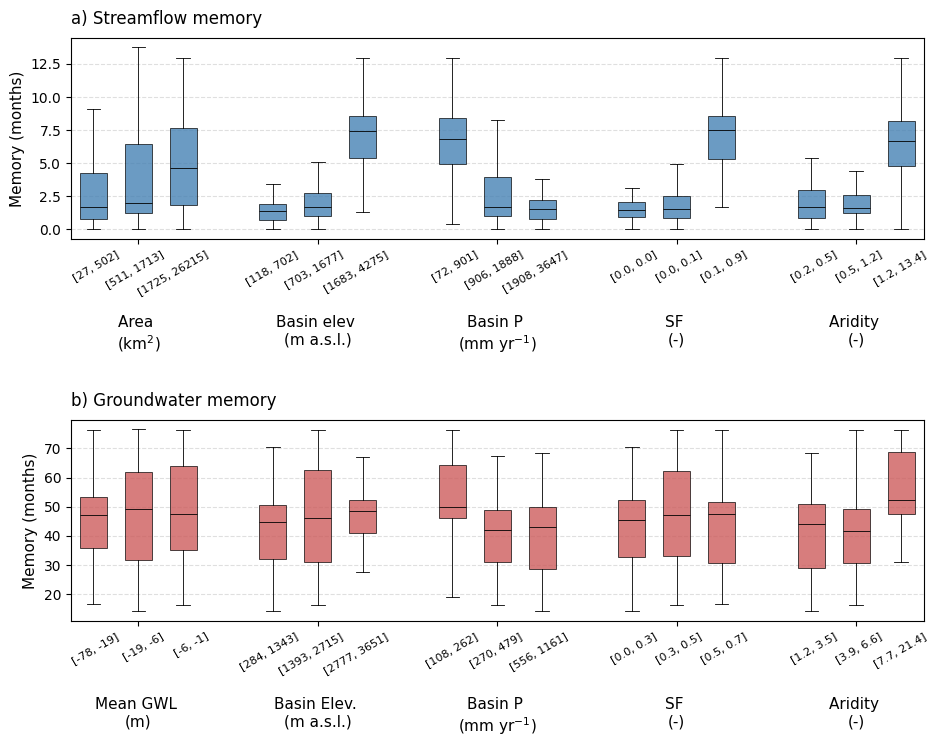

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) LOAD DATA
# =========================
q_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv2/gw_memory.csv').rename(columns={'well_id': 'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory_data['gauge_id'] = q_memory_data['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)
gw_memory_data['cr2sub_id'] = gw_memory_data['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] = q_attrib['p_mean_cr2met_1979_2010'] * 365

# =========================
# 2) SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# 3) MERGE
# =========================
q_df = q_memory_data.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory_data.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

q_vars = [c for c in q_attrib_sel if c != 'gauge_id']
gw_vars = [c for c in gw_attrib_sel if c != 'cr2sub_id']

for col in q_vars + ['q_memory']:
    q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_vars + ['gw_memory']:
    gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# 4) SHORT NAMES
# =========================
q_short = {
    'area_km2': 'Area \n(km$^2$)',
    'mean_elev': 'Basin elev \n(m a.s.l.)',
    'p_mean_cr2met_1979_2010': 'Basin P \n(mm yr$^{-1}$)',
    'frac_snow_cr2met_1979_2010': 'SF \n(-)',
    'aridity_cr2met_1979_2010': 'Aridity \n(-)'
}

gw_short = {
    'cr2sub_clean_mean_gwl': 'Mean GWL \n(m)',
    'cr2sub_camels_elev': 'Basin Elev. \n(m a.s.l.)',
    'cr2sub_camels_pr_yr': 'Basin P \n(mm yr$^{-1}$)',
    'cr2sub_camels_sf': 'SF \n(-)',
    'cr2sub_camels_aridity': 'Aridity \n(-)'
}

labels = ['Low', 'Medium', 'High']
# col_q = 'forestgreen'
# col_gw = 'orangered'

col_q = 'steelblue'
col_gw = 'indianred'

# solo SF y aridity llevan decimales, el resto se muestra sin decimales
def fmt_range_value(x, var_name):
    if 'sf' in var_name.lower() or 'snow' in var_name.lower() or 'aridity' in var_name.lower():
        return f'{x:.1f}'
    else:
        return f'{x:.0f}'
    
    
# =========================
# 5) FIGURE
# =========================
fig, axes = plt.subplots(2, 1, figsize=(11, 11), constrained_layout=False)

# =========================
# 6) STREAMFLOW
# =========================
xticks_q = []
xlabels_q = []
q_range_positions = []
q_range_texts = []

for i, var in enumerate(q_vars):
    df = q_df[['q_memory', var]].dropna().copy()

    bins = df[var].quantile([0, 1/3, 2/3, 1]).values
    bins[1] = bins[1] + 1e-6
    bins[2] = bins[2] + 2e-6

    df['group'] = pd.cut(df[var], bins=bins, labels=labels, include_lowest=True)

    data = [df.loc[df['group'] == g, 'q_memory'] for g in labels]
    mins = [df.loc[df['group'] == g, var].min() for g in labels]
    maxs = [df.loc[df['group'] == g, var].max() for g in labels]

    pos = np.arange(3) + i * 4

    bp = axes[0].boxplot(
        data,
        positions=pos,
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )

    for patch in bp['boxes']:
        patch.set_facecolor(col_q)
        patch.set_alpha(0.8)

    for item in ['boxes', 'whiskers', 'caps']:
        for obj in bp[item]:
            obj.set_linewidth(0.6)

    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(0.6)

    xticks_q.append(pos[1])
    xlabels_q.append(q_short[var])

    q_range_positions.append(pos.copy())
    
    q_range_texts.append([
        f'[{fmt_range_value(mins[0], var)}, {fmt_range_value(maxs[0], var)}]',
        f'[{fmt_range_value(mins[1], var)}, {fmt_range_value(maxs[1], var)}]',
        f'[{fmt_range_value(mins[2], var)}, {fmt_range_value(maxs[2], var)}]'
    ])

axes[0].set_title('a) Streamflow memory', loc='left', pad=10)
axes[0].set_ylabel('Memory (months)', fontsize=11)
axes[0].set_xticks(xticks_q)
axes[0].set_xticklabels([''] * len(xticks_q))
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

y0 = axes[0].get_ylim()[0]
dy = axes[0].get_ylim()[1] - axes[0].get_ylim()[0]

offset = 0.6
offsety_range = 0.05
offsety_name = 0.38

for pos, txts in zip(q_range_positions, q_range_texts):
    axes[0].text(pos[0] + offset, y0 - offsety_range * dy, txts[0], ha='right', va='top', rotation=30, fontsize=8)
    axes[0].text(pos[1] + offset, y0 - offsety_range * dy, txts[1], ha='right', va='top', rotation=30, fontsize=8)
    axes[0].text(pos[2] + offset, y0 - offsety_range * dy, txts[2], ha='right', va='top', rotation=30, fontsize=8)

for x, name in zip(xticks_q, xlabels_q):
    axes[0].text(x, y0 - offsety_name * dy, name, ha='center', va='top', fontsize=11)

# =========================
# 7) GROUNDWATER
# =========================
xticks_gw = []
xlabels_gw = []
gw_range_positions = []
gw_range_texts = []

for i, var in enumerate(gw_vars):
    df = gw_df[['gw_memory', var]].dropna().copy()

    bins = df[var].quantile([0, 1/3, 2/3, 1]).values
    bins[1] = bins[1] + 1e-6
    bins[2] = bins[2] + 2e-6

    df['group'] = pd.cut(df[var], bins=bins, labels=labels, include_lowest=True)

    data = [df.loc[df['group'] == g, 'gw_memory'] for g in labels]
    mins = [df.loc[df['group'] == g, var].min() for g in labels]
    maxs = [df.loc[df['group'] == g, var].max() for g in labels]

    pos = np.arange(3) + i * 4

    bp = axes[1].boxplot(
        data,
        positions=pos,
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )

    for patch in bp['boxes']:
        patch.set_facecolor(col_gw)
        patch.set_alpha(0.8)

    for item in ['boxes', 'whiskers', 'caps']:
        for obj in bp[item]:
            obj.set_linewidth(0.6)

    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(0.6)

    xticks_gw.append(pos[1])
    xlabels_gw.append(gw_short[var])

    gw_range_positions.append(pos.copy())
    gw_range_texts.append([
        f'[{fmt_range_value(mins[0], var)}, {fmt_range_value(maxs[0], var)}]',
        f'[{fmt_range_value(mins[1], var)}, {fmt_range_value(maxs[1], var)}]',
        f'[{fmt_range_value(mins[2], var)}, {fmt_range_value(maxs[2], var)}]'
    ])

axes[1].set_title('b) Groundwater memory', loc='left', pad=10)
axes[1].set_ylabel('Memory (months)', fontsize=11)
axes[1].set_xticks(xticks_gw)
axes[1].set_xticklabels([''] * len(xticks_gw))
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

y0 = axes[1].get_ylim()[0]
dy = axes[1].get_ylim()[1] - axes[1].get_ylim()[0]

for pos, txts in zip(gw_range_positions, gw_range_texts):
    axes[1].text(pos[0] + offset, y0 - offsety_range * dy, txts[0], ha='right', va='top', rotation=30, fontsize=8)
    axes[1].text(pos[1] + offset, y0 - offsety_range * dy, txts[1], ha='right', va='top', rotation=30, fontsize=8)
    axes[1].text(pos[2] + offset, y0 - offsety_range * dy, txts[2], ha='right', va='top', rotation=30, fontsize=8)

for x, name in zip(xticks_gw, xlabels_gw):
    axes[1].text(x, y0 - offsety_name * dy, name, ha='center', va='top', fontsize=11)

plt.subplots_adjust(hspace=0.9, bottom=0.35)
plt.savefig('Fig7_memory_boxplots2.png', dpi=300, bbox_inches='tight')

plt.show()

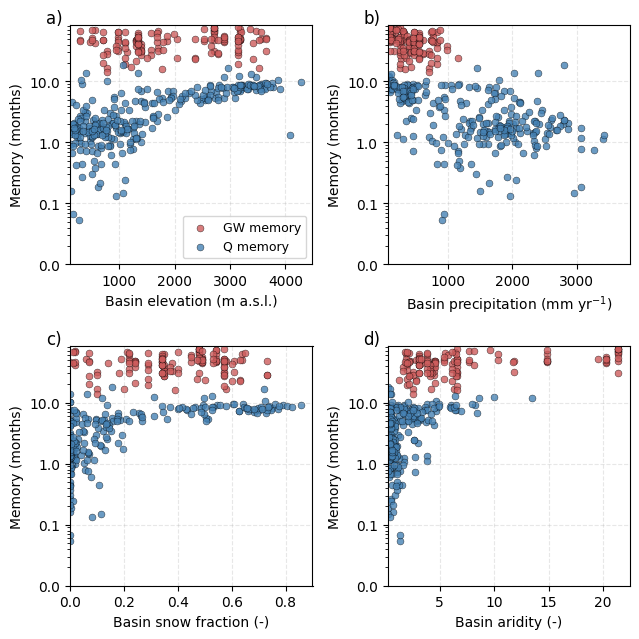

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator

# =========================
# LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv2/gw_memory.csv').rename(columns={'well_id':'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] *= 365

# =========================
# SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# MERGE
# =========================
q_df = q_memory.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

for col in q_df.columns:
    if col != 'gauge_id':
        q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_df.columns:
    if col != 'cr2sub_id':
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# COMMON Y LIMITS
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# un pequeño margen
ypad = 0.05 * (ymax - ymin)
ymin = ymin - ypad
ymax = ymax + ypad

# =========================
# COMMON Y LIMITS (LOG SAFE)
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# evitar valores <= 0
ymin = max(ymin, 0.01)

ypad = 0.1 * (ymax - ymin)
ymax = ymax + ypad

# =========================
# COMMON SCATTERS: Q + GW
# =========================
common_pairs = [
    ('mean_elev', 'cr2sub_camels_elev', 'Basin elevation (m a.s.l.)'),
    ('p_mean_cr2met_1979_2010', 'cr2sub_camels_pr_yr', 'Basin precipitation (mm yr$^{-1}$)'),
    ('frac_snow_cr2met_1979_2010', 'cr2sub_camels_sf', 'Basin snow fraction (-)'),
    ('aridity_cr2met_1979_2010', 'cr2sub_camels_aridity', 'Basin aridity (-)')
]

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.5))
axes = axes.flatten()

col_q = 'steelblue'
col_gw = 'indianred'
pt_sz = 25
panel_labels = ['a)', 'b)', 'c)', 'd)']

for i, (q_var, gw_var, xlabel) in enumerate(common_pairs):
    ax = axes[i]

    q_sub = q_df[[q_var, 'q_memory']].dropna()
    gw_sub = gw_df[[gw_var, 'gw_memory']].dropna()

    ax.scatter(
        gw_sub[gw_var],
        gw_sub['gw_memory'],
        s=pt_sz,
        alpha=0.8,
        color=col_gw,
        label='GW memory',
        edgecolor='black',
        linewidth=0.3,        
    )

    ax.scatter(
        q_sub[q_var],
        q_sub['q_memory'],
        s=pt_sz,
        alpha=0.8,
        color= col_q,
        label='Q memory',
        edgecolor='black',
        linewidth=0.3,
    )

    xmin = min(q_sub[q_var].min(), gw_sub[gw_var].min()) * 0.95
    xmax = max(q_sub[q_var].max(), gw_sub[gw_var].max()) * 1.05

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Memory (months)')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_yscale('log')   
    # ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis='y', style='plain')
    
    ax.text(
        -0.1, 0.99, panel_labels[i],
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=12
    )


# legend only once
axes[0].legend(frameon=True, fontsize=9, loc='lower right')

# plt.suptitle('Hydrological memory vs attributes')
plt.tight_layout()
# plt.subplots_adjust(hspace=0.35, bottom=0.35)
plt.savefig('Fig7_memory_scatter.png', dpi=300, bbox_inches='tight')


plt.show()

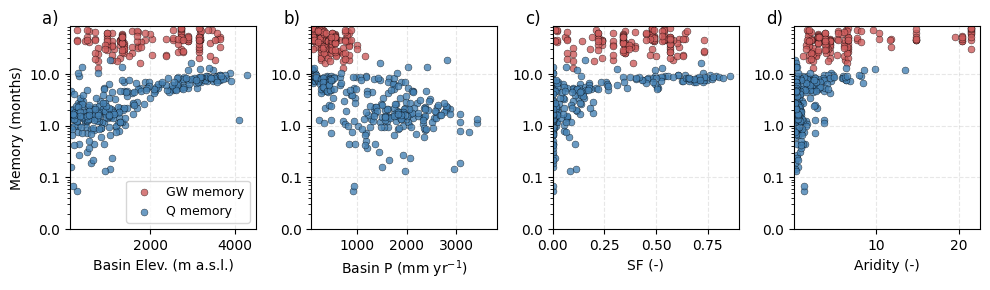

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator

# =========================
# LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv').rename(columns={'well_id':'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] *= 365

# =========================
# SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# MERGE
# =========================
q_df = q_memory.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

for col in q_df.columns:
    if col != 'gauge_id':
        q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_df.columns:
    if col != 'cr2sub_id':
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# COMMON Y LIMITS
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# un pequeño margen
ypad = 0.05 * (ymax - ymin)
ymin = ymin - ypad
ymax = ymax + ypad

# =========================
# COMMON Y LIMITS (LOG SAFE)
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# evitar valores <= 0
ymin = max(ymin, 0.01)

ypad = 0.1 * (ymax - ymin)
ymax = ymax + ypad

# =========================
# COMMON SCATTERS: Q + GW
# =========================
common_pairs = [
    ('mean_elev', 'cr2sub_camels_elev', 'Basin Elev. (m a.s.l.)'),
    ('p_mean_cr2met_1979_2010', 'cr2sub_camels_pr_yr', 'Basin P (mm yr$^{-1}$)'),
    ('frac_snow_cr2met_1979_2010', 'cr2sub_camels_sf', 'SF (-)'),
    ('aridity_cr2met_1979_2010', 'cr2sub_camels_aridity', 'Aridity (-)')
]

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes = axes.flatten()

col_q = 'steelblue'
col_gw = 'indianred'
pt_sz = 25
panel_labels = ['a)', 'b)', 'c)', 'd)']

for i, (q_var, gw_var, xlabel) in enumerate(common_pairs):
    ax = axes[i]

    q_sub = q_df[[q_var, 'q_memory']].dropna()
    gw_sub = gw_df[[gw_var, 'gw_memory']].dropna()

    ax.scatter(
        gw_sub[gw_var],
        gw_sub['gw_memory'],
        s=pt_sz,
        alpha=0.8,
        color=col_gw,
        label='GW memory',
        edgecolor='black',
        linewidth=0.3,        
    )

    ax.scatter(
        q_sub[q_var],
        q_sub['q_memory'],
        s=pt_sz,
        alpha=0.8,
        color= col_q,
        label='Q memory',
        edgecolor='black',
        linewidth=0.3,
    )

    xmin = min(q_sub[q_var].min(), gw_sub[gw_var].min()) * 0.95
    xmax = max(q_sub[q_var].max(), gw_sub[gw_var].max()) * 1.05

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(xlabel)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_yscale('log')   
    # ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis='y', style='plain')
    
    ax.text(
        -0.15, 0.99, panel_labels[i],
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=12
    )
    
    if i==0:
        ax.set_ylabel('Memory (months)')


# legend only once
axes[0].legend(frameon=True, fontsize=9, loc='lower right')

# plt.suptitle('Hydrological memory vs attributes')
plt.tight_layout()
# plt.subplots_adjust(hspace=0.35, bottom=0.35)
plt.savefig('Fig7_memory_scatter2.png', dpi=300, bbox_inches='tight')


plt.show()

### Exploratory figures ###

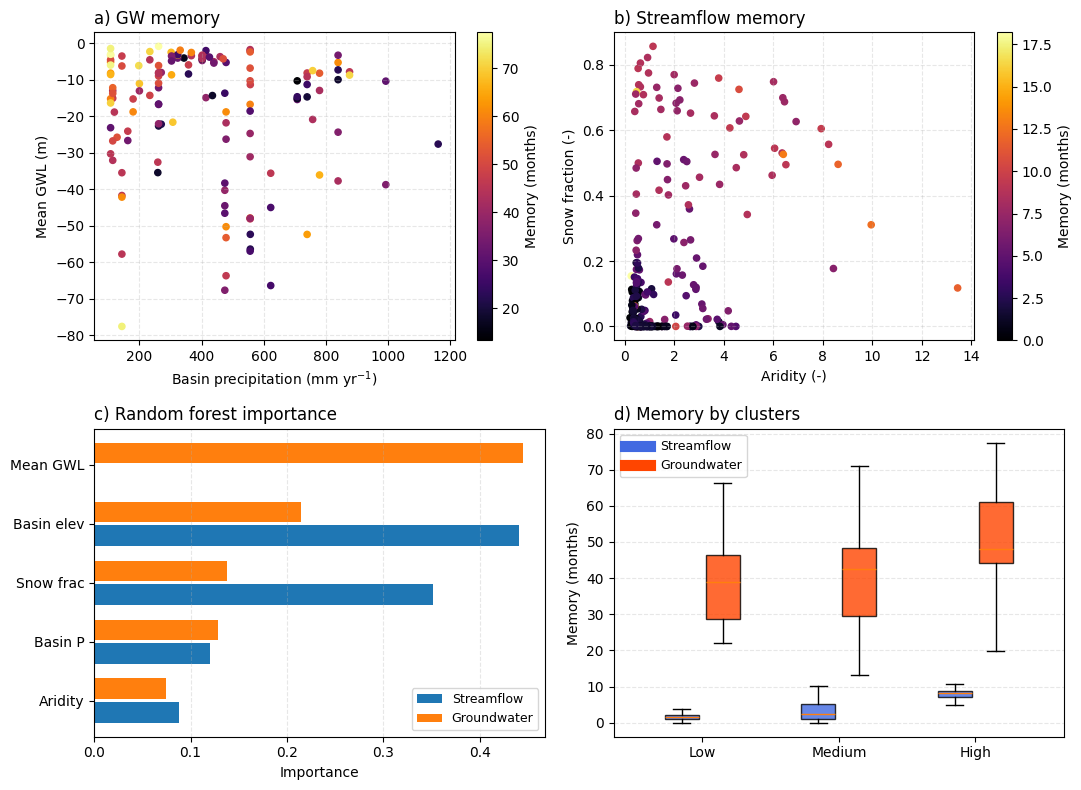

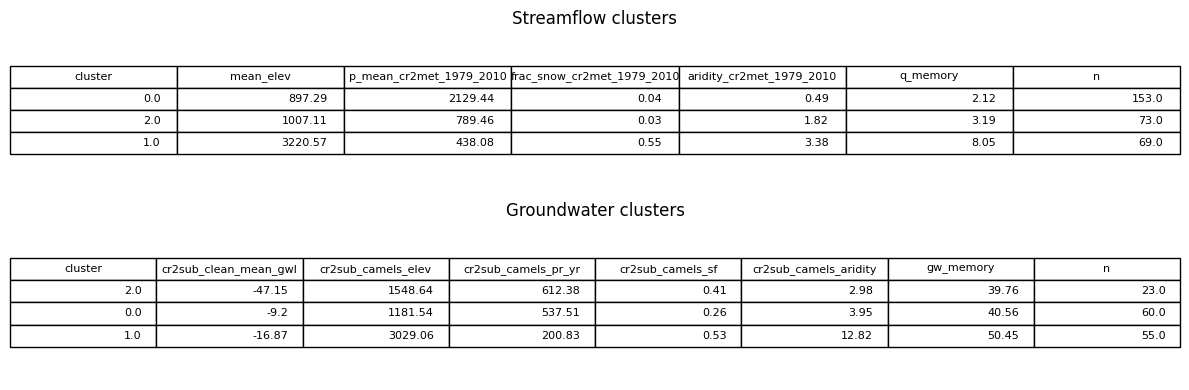

         mean_elev  p_mean_cr2met_1979_2010  frac_snow_cr2met_1979_2010  \
cluster                                                                   
0           897.29                  2129.44                        0.04   
2          1007.11                   789.46                        0.03   
1          3220.57                   438.08                        0.55   

         aridity_cr2met_1979_2010  q_memory    n  
cluster                                           
0                            0.49      2.12  153  
2                            1.82      3.19   73  
1                            3.38      8.05   69  
         cr2sub_clean_mean_gwl  cr2sub_camels_elev  cr2sub_camels_pr_yr  \
cluster                                                                   
2                       -47.15             1548.64               612.38   
0                        -9.20             1181.54               537.51   
1                       -16.87             3029.06               200.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================
# 1) LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv').rename(columns={'well_id': 'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] = q_attrib['p_mean_cr2met_1979_2010'] * 365

# =========================
# 2) SELECT VARIABLES
# =========================
q_cols = [
    'gauge_id',
    'q_memory',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_cols = [
    'cr2sub_id',
    'gw_memory',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# 3) MERGE
# =========================
q_df = q_memory.merge(q_attrib, on='gauge_id', how='left')[q_cols]
gw_df = gw_memory.merge(gw_attrib, on='cr2sub_id', how='left')[gw_cols]

for col in q_cols[1:]:
    q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_cols[1:]:
    gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

q_df = q_df.dropna().copy()
gw_df = gw_df.dropna().copy()

# =========================
# 4) RANDOM FOREST
# =========================
q_xcols = ['mean_elev', 'p_mean_cr2met_1979_2010', 'frac_snow_cr2met_1979_2010', 'aridity_cr2met_1979_2010']
gw_xcols = ['cr2sub_clean_mean_gwl', 'cr2sub_camels_elev', 'cr2sub_camels_pr_yr', 'cr2sub_camels_sf', 'cr2sub_camels_aridity']

rf_q = RandomForestRegressor(n_estimators=300, random_state=0)
rf_gw = RandomForestRegressor(n_estimators=300, random_state=0)

rf_q.fit(q_df[q_xcols], q_df['q_memory'])
rf_gw.fit(gw_df[gw_xcols], gw_df['gw_memory'])

q_importance = pd.Series(rf_q.feature_importances_, index=q_xcols).sort_values(ascending=True)
gw_importance = pd.Series(rf_gw.feature_importances_, index=gw_xcols).sort_values(ascending=True)

# =========================
# 5) CLUSTERS
# =========================
scaler_q = StandardScaler()
scaler_gw = StandardScaler()

q_scaled = scaler_q.fit_transform(q_df[q_xcols])
gw_scaled = scaler_gw.fit_transform(gw_df[gw_xcols])

kmeans_q = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_gw = KMeans(n_clusters=3, random_state=0, n_init=10)

q_df['cluster'] = kmeans_q.fit_predict(q_scaled)
gw_df['cluster'] = kmeans_gw.fit_predict(gw_scaled)

# reorder clusters by mean memory
q_order = q_df.groupby('cluster')['q_memory'].mean().sort_values().index.tolist()
gw_order = gw_df.groupby('cluster')['gw_memory'].mean().sort_values().index.tolist()

q_box_data = [q_df.loc[q_df['cluster'] == c, 'q_memory'] for c in q_order]
gw_box_data = [gw_df.loc[gw_df['cluster'] == c, 'gw_memory'] for c in gw_order]

# =========================
# 6) FIGURE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# --- panel a: GW scatter ---
sc1 = axes[0, 0].scatter(
    gw_df['cr2sub_camels_pr_yr'],
    gw_df['cr2sub_clean_mean_gwl'],
    c=gw_df['gw_memory'],
    cmap='inferno',
    s=20
)
axes[0, 0].set_title('a) GW memory', loc='left')
axes[0, 0].set_xlabel('Basin precipitation (mm yr$^{-1}$)')
axes[0, 0].set_ylabel('Mean GWL (m)')
axes[0, 0].grid(True, linestyle='--', alpha=0.3)
cbar1 = plt.colorbar(sc1, ax=axes[0, 0])
cbar1.set_label('Memory (months)')

# --- panel b: Q scatter ---
sc2 = axes[0, 1].scatter(
    q_df['aridity_cr2met_1979_2010'],
    q_df['frac_snow_cr2met_1979_2010'],
    c=q_df['q_memory'],
    cmap='inferno',
    s=20
)
axes[0, 1].set_title('b) Streamflow memory', loc='left')
axes[0, 1].set_xlabel('Aridity (-)')
axes[0, 1].set_ylabel('Snow fraction (-)')
axes[0, 1].grid(True, linestyle='--', alpha=0.3)
cbar2 = plt.colorbar(sc2, ax=axes[0, 1])
cbar2.set_label('Memory (months)')

# --- panel c: RF importance ---
y_q = np.arange(len(q_importance))
y_gw = np.arange(len(gw_importance))

axes[1, 0].barh(y_q - 0.2, q_importance.values, height=0.35, label='Streamflow')
axes[1, 0].barh(y_gw + 0.2, gw_importance.values, height=0.35, label='Groundwater')

all_names = list(q_importance.index) + list(gw_importance.index)
all_names_short = {
    'mean_elev': 'Basin elev',
    'p_mean_cr2met_1979_2010': 'Basin P',
    'frac_snow_cr2met_1979_2010': 'Snow frac',
    'aridity_cr2met_1979_2010': 'Aridity',
    'cr2sub_clean_mean_gwl': 'Mean GWL',
    'cr2sub_camels_elev': 'Basin elev',
    'cr2sub_camels_pr_yr': 'Basin P',
    'cr2sub_camels_sf': 'Snow frac',
    'cr2sub_camels_aridity': 'Aridity'
}

max_len = max(len(q_importance), len(gw_importance))
yticks = np.arange(max_len)
yticklabels = []
for i in range(max_len):
    q_name = q_importance.index[i] if i < len(q_importance) else ''
    gw_name = gw_importance.index[i] if i < len(gw_importance) else ''
    if q_name != '':
        yticklabels.append(all_names_short[q_name])
    else:
        yticklabels.append(all_names_short[gw_name])

axes[1, 0].set_yticks(yticks)
axes[1, 0].set_yticklabels(yticklabels)
axes[1, 0].set_title('c) Random forest importance', loc='left')
axes[1, 0].set_xlabel('Importance')
axes[1, 0].legend(frameon=True, fontsize=9)
axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.3)

# --- panel d: cluster boxplots ---
bp1 = axes[1, 1].boxplot(
    q_box_data,
    positions=[0.85, 1.85, 2.85],
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

bp2 = axes[1, 1].boxplot(
    gw_box_data,
    positions=[1.15, 2.15, 3.15],
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for patch in bp1['boxes']:
    patch.set_facecolor('royalblue')
    patch.set_alpha(0.8)

for patch in bp2['boxes']:
    patch.set_facecolor('orangered')
    patch.set_alpha(0.8)

axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1, 1].set_ylabel('Memory (months)')
axes[1, 1].set_title('d) Memory by clusters', loc='left')
axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.3)
axes[1, 1].legend(
    handles=[
        plt.Line2D([0], [0], color='royalblue', lw=8, label='Streamflow'),
        plt.Line2D([0], [0], color='orangered', lw=8, label='Groundwater')
    ],
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


# order clusters by mean memory
q_order = q_df.groupby('cluster')['q_memory'].mean().sort_values().index
gw_order = gw_df.groupby('cluster')['gw_memory'].mean().sort_values().index

# print('\n=== Streamflow cluster characteristics (ordered by memory) ===')
q_summary = q_df.groupby('cluster')[q_xcols + ['q_memory']].mean().round(2).loc[q_order]
q_summary['n'] = q_df.groupby('cluster').size().loc[q_order]

# print('\n=== Groundwater cluster characteristics (ordered by memory) ===')
gw_summary = gw_df.groupby('cluster')[gw_xcols + ['gw_memory']].mean().round(2).loc[gw_order]
gw_summary['n'] = gw_df.groupby('cluster').size().loc[gw_order]


fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].axis('off')
axes[1].axis('off')

table_q = axes[0].table(
    cellText=q_summary.reset_index().values,
    colLabels=q_summary.reset_index().columns,
    loc='center'
)
table_q.auto_set_font_size(False)
table_q.set_fontsize(8)
table_q.scale(1, 1.2)
axes[0].set_title('Streamflow clusters')

table_gw = axes[1].table(
    cellText=gw_summary.reset_index().values,
    colLabels=gw_summary.reset_index().columns,
    loc='center'
)
table_gw.auto_set_font_size(False)
table_gw.set_fontsize(8)
table_gw.scale(1, 1.2)
axes[1].set_title('Groundwater clusters')

plt.tight_layout()
plt.show()

print(q_summary)
print(gw_summary)

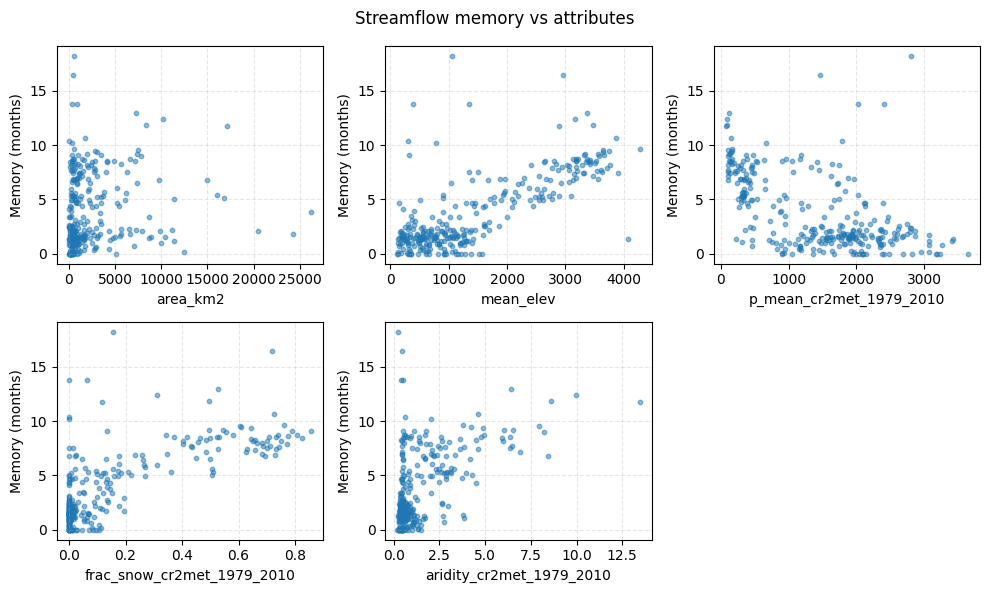

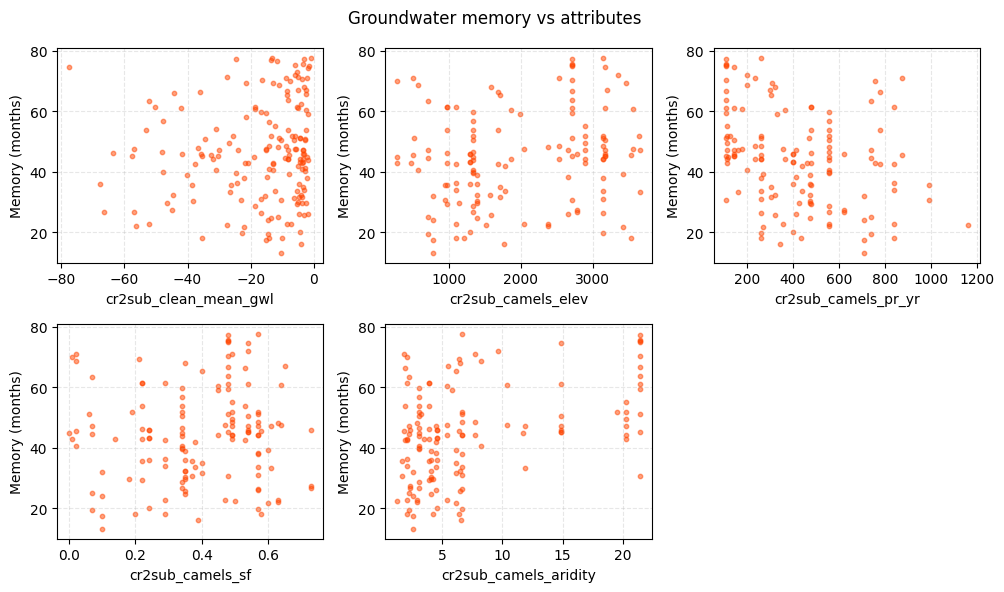

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv').rename(columns={'well_id':'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] *= 365

# =========================
# SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# MERGE
# =========================
q_df = q_memory.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

for col in q_df.columns:
    if col != 'gauge_id':
        q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_df.columns:
    if col != 'cr2sub_id':
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# STREAMFLOW SCATTERS
# =========================
q_vars = [
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

fig, axes = plt.subplots(2,3, figsize=(10,6))
axes = axes.flatten()

for i,var in enumerate(q_vars):

    axes[i].scatter(
        q_df[var],
        q_df['q_memory'],
        s=10,
        alpha=0.5
    )

    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Memory (months)')
    axes[i].grid(True, linestyle='--', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Streamflow memory vs attributes')
plt.tight_layout()
plt.show()

# =========================
# GROUNDWATER SCATTERS
# =========================
gw_vars = [
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

fig, axes = plt.subplots(2,3, figsize=(10,6))
axes = axes.flatten()

for i,var in enumerate(gw_vars):

    axes[i].scatter(
        gw_df[var],
        gw_df['gw_memory'],
        s=10,
        alpha=0.5,
        color='orangered'
    )

    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Memory (months)')
    axes[i].grid(True, linestyle='--', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Groundwater memory vs attributes')
plt.tight_layout()
plt.show()

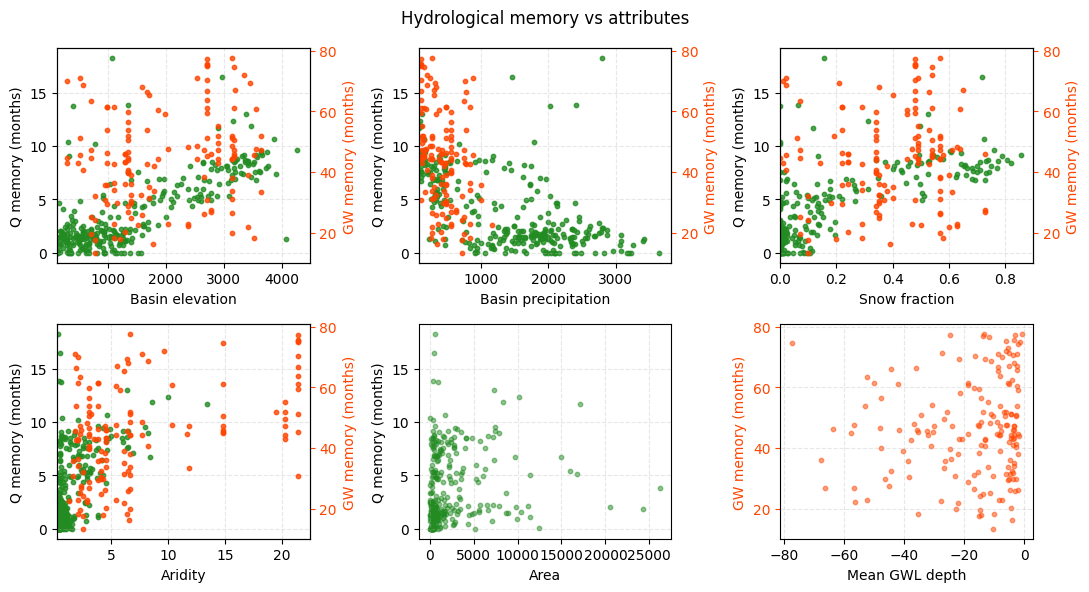

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv').rename(columns={'well_id':'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] *= 365

# =========================
# SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# MERGE
# =========================
q_df = q_memory.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

for col in q_df.columns:
    if col != 'gauge_id':
        q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_df.columns:
    if col != 'cr2sub_id':
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# COMMON SCATTERS: Q + GW
# =========================
common_pairs = [
    ('mean_elev', 'cr2sub_camels_elev', 'Basin elevation'),
    ('p_mean_cr2met_1979_2010', 'cr2sub_camels_pr_yr', 'Basin precipitation'),
    ('frac_snow_cr2met_1979_2010', 'cr2sub_camels_sf', 'Snow fraction'),
    ('aridity_cr2met_1979_2010', 'cr2sub_camels_aridity', 'Aridity')
]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()

col_q = 'forestgreen'
col_gw = 'orangered'

for i, (q_var, gw_var, xlabel) in enumerate(common_pairs):
    ax = axes[i]
    ax2 = ax.twinx()

    q_sub = q_df[[q_var, 'q_memory']].dropna()
    gw_sub = gw_df[[gw_var, 'gw_memory']].dropna()

    ax2.scatter(
        gw_sub[gw_var],
        gw_sub['gw_memory'],
        s=10,
        alpha=0.8,
        color=col_gw
    )

    ax.scatter(
        q_sub[q_var],
        q_sub['q_memory'],
        s=10,
        alpha=0.8,
        color=col_q
    )
    
    xmin = min(q_sub[q_var].min(), gw_sub[gw_var].min())*0.95
    xmax = max(q_sub[q_var].max(), gw_sub[gw_var].max())*1.05
    ax.set_xlim(xmin, xmax)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Q memory (months)', color='black')
    ax2.set_ylabel('GW memory (months)', color=col_gw)

    ax.tick_params(axis='y', colors='black')
    ax2.tick_params(axis='y', colors=col_gw)

    ax.grid(True, linestyle='--', alpha=0.3)

# =========================
# Q ONLY: AREA
# =========================
q_sub = q_df[['area_km2', 'q_memory']].dropna()

axes[4].scatter(
    q_sub['area_km2'],
    q_sub['q_memory'],
    s=10,
    alpha=0.5,
    color=col_q
)
axes[4].set_xlabel('Area')
axes[4].set_ylabel('Q memory (months)', color='black')
axes[4].tick_params(axis='y', colors='black')
axes[4].grid(True, linestyle='--', alpha=0.3)

# =========================
# GW ONLY: MEAN GWL DEPTH
# =========================
gw_sub = gw_df[['cr2sub_clean_mean_gwl', 'gw_memory']].dropna()

axes[5].scatter(
    gw_sub['cr2sub_clean_mean_gwl'],
    gw_sub['gw_memory'],
    s=10,
    alpha=0.5,
    color=col_gw
)
axes[5].set_xlabel('Mean GWL depth')
axes[5].set_ylabel('GW memory (months)', color=col_gw)
axes[5].tick_params(axis='y', colors=col_gw)
axes[5].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Hydrological memory vs attributes')
plt.tight_layout()
plt.show()

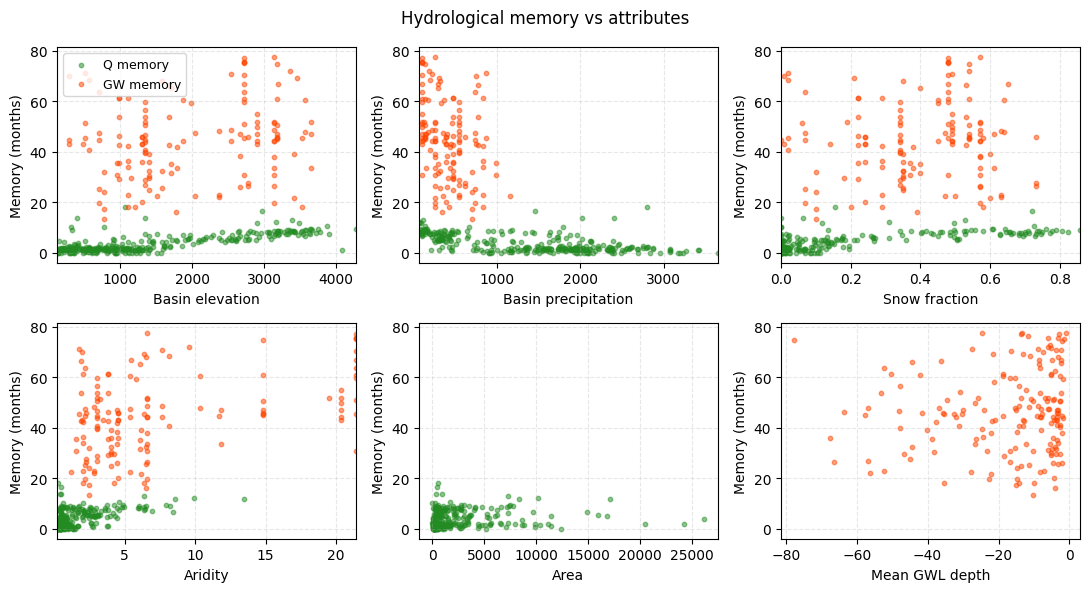

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
q_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_memory = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv').rename(columns={'well_id':'cr2sub_id'})

q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')

q_memory['gauge_id'] = q_memory['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)

gw_memory['cr2sub_id'] = gw_memory['cr2sub_id'].astype(str)
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)

q_attrib['p_mean_cr2met_1979_2010'] *= 365

# =========================
# SELECT ATTRIBUTES
# =========================
q_attrib_sel = [
    'gauge_id',
    'area_km2',
    'mean_elev',
    'p_mean_cr2met_1979_2010',
    'frac_snow_cr2met_1979_2010',
    'aridity_cr2met_1979_2010'
]

gw_attrib_sel = [
    'cr2sub_id',
    'cr2sub_clean_mean_gwl',
    'cr2sub_camels_elev',
    'cr2sub_camels_pr_yr',
    'cr2sub_camels_sf',
    'cr2sub_camels_aridity'
]

# =========================
# MERGE
# =========================
q_df = q_memory.merge(q_attrib[q_attrib_sel], on='gauge_id', how='left')
gw_df = gw_memory.merge(gw_attrib[gw_attrib_sel], on='cr2sub_id', how='left')

for col in q_df.columns:
    if col != 'gauge_id':
        q_df[col] = pd.to_numeric(q_df[col], errors='coerce')

for col in gw_df.columns:
    if col != 'cr2sub_id':
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

# =========================
# COMMON Y LIMITS
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# un pequeño margen
ypad = 0.05 * (ymax - ymin)
ymin = ymin - ypad
ymax = ymax + ypad

# =========================
# COMMON Y LIMITS (LOG SAFE)
# =========================
ymin = min(q_df['q_memory'].min(), gw_df['gw_memory'].min())
ymax = max(q_df['q_memory'].max(), gw_df['gw_memory'].max())

# evitar valores <= 0
ymin = max(ymin, 0.1)

ypad = 0.05 * (ymax - ymin)
ymax = ymax + ypad

# =========================
# COMMON SCATTERS: Q + GW
# =========================
common_pairs = [
    ('mean_elev', 'cr2sub_camels_elev', 'Basin elevation'),
    ('p_mean_cr2met_1979_2010', 'cr2sub_camels_pr_yr', 'Basin precipitation'),
    ('frac_snow_cr2met_1979_2010', 'cr2sub_camels_sf', 'Snow fraction'),
    ('aridity_cr2met_1979_2010', 'cr2sub_camels_aridity', 'Aridity')
]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()

for i, (q_var, gw_var, xlabel) in enumerate(common_pairs):
    ax = axes[i]

    q_sub = q_df[[q_var, 'q_memory']].dropna()
    gw_sub = gw_df[[gw_var, 'gw_memory']].dropna()

    ax.scatter(
        q_sub[q_var],
        q_sub['q_memory'],
        s=10,
        alpha=0.5,
        color='forestgreen',
        label='Q memory'
    )

    ax.scatter(
        gw_sub[gw_var],
        gw_sub['gw_memory'],
        s=10,
        alpha=0.5,
        color='orangered',
        label='GW memory'
    )

    xmin = min(q_sub[q_var].min(), gw_sub[gw_var].min())
    xmax = max(q_sub[q_var].max(), gw_sub[gw_var].max())

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Memory (months)')
    ax.grid(True, linestyle='--', alpha=0.3)

# =========================
# Q ONLY: AREA
# =========================
q_sub = q_df[['area_km2', 'q_memory']].dropna()

axes[4].scatter(
    q_sub['area_km2'],
    q_sub['q_memory'],
    s=10,
    alpha=0.5,
    color='forestgreen'
)
axes[4].set_xlabel('Area')
axes[4].set_ylabel('Memory (months)')
axes[4].set_ylim(ymin, ymax)
axes[4].grid(True, linestyle='--', alpha=0.3)

# =========================
# GW ONLY: MEAN GWL DEPTH
# =========================
gw_sub = gw_df[['cr2sub_clean_mean_gwl', 'gw_memory']].dropna()

axes[5].scatter(
    gw_sub['cr2sub_clean_mean_gwl'],
    gw_sub['gw_memory'],
    s=10,
    alpha=0.5,
    color='orangered'
)
axes[5].set_xlabel('Mean GWL depth')
axes[5].set_ylabel('Memory (months)')
axes[5].set_ylim(ymin, ymax)
axes[5].grid(True, linestyle='--', alpha=0.3)

# legend only once
axes[1].legend(frameon=True, fontsize=9)

plt.suptitle('Hydrological memory vs attributes')
plt.tight_layout()
plt.show()

#### Fig. hydromemory maps with singles colorbar

/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_37551/734573110.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_list = cm.get_cmap('inferno')(np.linspace(1, 0, len(bins) - 1))


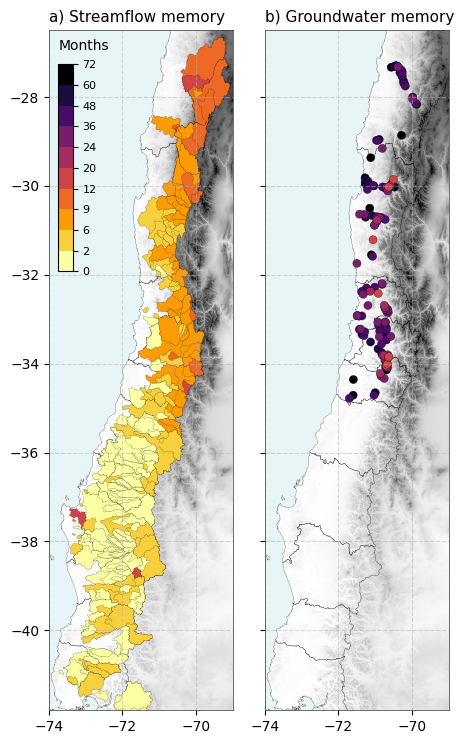

In [74]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
import matplotlib.cm as cm

# =========================
# 1) LOAD DATA
# =========================

# Streamflow
q_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

q_memory_data['gauge_id'] = q_memory_data['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)

# Groundwater
gw_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv')
gw_memory_data = gw_memory_data.rename(columns={'well_id': 'cr2sub_id'})

gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)
gw_memory_data['cr2sub_id'] = gw_memory_data['cr2sub_id'].astype(str)

gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
gwl_gpkg['cr2sub_id'] = gwl_gpkg['cr2sub_id'].astype(str)

# Merge memory with geometries
q_gpkg = q_gpkg.merge(q_memory_data, on='gauge_id', how='left')
gwl_gpkg = gwl_gpkg.merge(gw_memory_data, on='cr2sub_id', how='left')

# Regions
regions_gdf = gpd.read_file('../data/other/cl_regiones_geo/cl_regiones_geo.shp')

# DEM
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

etopo_ds = xr.open_dataset('../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc')
dem = etopo_ds['z']
dem = slice_dim(dem, 'lon', min_lon, max_lon)
dem = slice_dim(dem, 'lat', min_lat, max_lat)

lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)
elevation_norm = plt.Normalize(vmin=0, vmax=6000)

# Keep only study area
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]
gwl_gpkg = gwl_gpkg[
    (gwl_gpkg.geometry.x >= min_lon) &
    (gwl_gpkg.geometry.x <= max_lon) &
    (gwl_gpkg.geometry.y >= min_lat) &
    (gwl_gpkg.geometry.y <= max_lat)
]

# =========================
# 2) COLOR SCALE FOR MEMORY MAPS
# =========================
q_bins = [0, 2, 6, 9, 12, 20]
gw_bins = [24, 36, 48, 60, 72]

bins = np.round(np.unique(np.concatenate([q_bins, gw_bins])), 2)
bins[0] = 0

cmap_list = cm.get_cmap('inferno')(np.linspace(1, 0, len(bins) - 1))
cmap = ListedColormap(cmap_list)
norm = BoundaryNorm(bins, cmap.N)

q_gpkg['bin_idx'] = pd.cut(
    q_gpkg['q_memory'],
    bins=bins,
    labels=False,
    right=True
)

gwl_gpkg['bin_idx'] = pd.cut(
    gwl_gpkg['gw_memory'],
    bins=bins,
    labels=False,
    right=True
)

q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='gw_memory', ascending=False)

# =========================
# 4) FIGURE
# =========================

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,6), constrained_layout=False)

fig = plt.figure(figsize=(12, 8))

width = 0.4
height = 0.85
x1 = 0.05
x2 = x1 + width - 0.22
x3 = x2 + width - 0.18

# === Create axes with manual placement ===
ax1 = fig.add_axes([x1, 0.1, width, height])  # [left, bottom, width, height]
ax2 = fig.add_axes([x2, 0.1, width, height])  # right panel slightly shifted


# aspect = 1 / np.cos(np.deg2rad((min_lat + max_lat) / 2))

# ax1.set_aspect(aspect)
# ax2.set_aspect(aspect)

# =========================
# 5) MAPS
# =========================
for ax in [ax1, ax2]:
    ax.set_facecolor(to_rgba('powderblue', 0.3))

    ax.pcolormesh(
        lon_grid, lat_grid, dem_masked,
        cmap=plt.cm.Greys,
        norm=elevation_norm,
        shading='auto'
    )

    regions_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_edgecolor('0.2')

q_gpkg.plot(
    ax=ax1,
    column='bin_idx',
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=len(bins) - 1),
    edgecolor='black',
    linewidth=0.1,
    alpha=1
)

gwl_gpkg.plot(
    ax=ax2,
    column='bin_idx',
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=len(bins) - 1),
    markersize=35,
    edgecolor='black',
    linewidth=0.2,
    alpha=1
)

ax1.set_title('a) Streamflow memory', loc='left', fontsize=11)
ax2.set_title('b) Groundwater memory', loc='left', fontsize=11)
ax2.set_yticklabels([])

# Common colorbar for maps
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = inset_axes(
    ax1, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .87),
    bbox_transform=ax1.transAxes, borderpad=0
)

cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.ax.set_title('Months', fontsize=10, loc='left', pad=10)
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_yticks(bins)
cbar.ax.set_yticklabels([f'{b:g}' for b in bins])

plt.subplots_adjust(wspace=0.0)
plt.savefig('Fig6_memory_map_single_cbar.png', dpi=300, bbox_inches='tight')
plt.show()

#### Fig. hydromemory maps with boxplots to the side

In [ ]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
import matplotlib.cm as cm

# =========================
# 1) LOAD DATA
# =========================

# Streamflow
q_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

q_memory_data['gauge_id'] = q_memory_data['gauge_id'].astype(str)
q_attrib['gauge_id'] = q_attrib['gauge_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)

# Groundwater
gw_memory_data = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv')
gw_memory_data = gw_memory_data.rename(columns={'well_id': 'cr2sub_id'})

gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv')
gw_attrib['cr2sub_id'] = gw_attrib['cr2sub_id'].astype(str)
gw_memory_data['cr2sub_id'] = gw_memory_data['cr2sub_id'].astype(str)

gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
gwl_gpkg['cr2sub_id'] = gwl_gpkg['cr2sub_id'].astype(str)

# Merge memory with geometries
q_gpkg = q_gpkg.merge(q_memory_data, on='gauge_id', how='left')
gwl_gpkg = gwl_gpkg.merge(gw_memory_data, on='cr2sub_id', how='left')

# Regions
regions_gdf = gpd.read_file('../data/other/cl_regiones_geo/cl_regiones_geo.shp')

# DEM
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

etopo_ds = xr.open_dataset('../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc')
dem = etopo_ds['z']
dem = slice_dim(elevation_etopo, 'lon', dem_min_lon, dem_max_lon)
dem = slice_dim(elevation_etopo, 'lat', dem_min_lat, dem_max_lat)

lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)
elevation_norm = plt.Normalize(vmin=0, vmax=6000)

# Keep only study area
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]
gwl_gpkg = gwl_gpkg[
    (gwl_gpkg.geometry.x >= min_lon) &
    (gwl_gpkg.geometry.x <= max_lon) &
    (gwl_gpkg.geometry.y >= min_lat) &
    (gwl_gpkg.geometry.y <= max_lat)
]

# =========================
# 2) COLOR SCALE FOR MEMORY MAPS
# =========================
q_bins = [0, 2, 6, 9, 12, 20]
gw_bins = [24, 36, 48, 60, 72]

bins = np.round(np.unique(np.concatenate([q_bins, gw_bins])), 2)
bins[0] = 0

cmap_list = cm.get_cmap('inferno')(np.linspace(1, 0, len(bins) - 1))
cmap = ListedColormap(cmap_list)
norm = BoundaryNorm(bins, cmap.N)

q_gpkg['bin_idx'] = pd.cut(
    q_gpkg['q_memory'],
    bins=bins,
    labels=False,
    right=True
)

gwl_gpkg['bin_idx'] = pd.cut(
    gwl_gpkg['gw_memory'],
    bins=bins,
    labels=False,
    right=True
)

q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='gw_memory', ascending=False)

# =========================
# 3) PREPARE DATA FOR BOXPLOTS
# =========================
labels = ['Low', 'Medium', 'High']

# Streamflow boxplot data
q_box_df = q_memory_data.merge(
    q_attrib[['gauge_id', 'p_mean_cr2met_1979_2010', 'frac_snow_cr2met_1979_2010', 'aridity_cr2met_1979_2010']],
    on='gauge_id',
    how='left'
)

# Groundwater boxplot data
gw_box_df = gw_memory_data.merge(
    gw_attrib[['cr2sub_id', 'cr2sub_camels_pr_yr', 'cr2sub_camels_sf', 'cr2sub_camels_aridity']],
    on='cr2sub_id',
    how='left'
)

# Precipitation groups
q_precip_bins = q_box_df['p_mean_cr2met_1979_2010'].quantile([0, 1/3, 2/3, 1]).values
q_precip_bins[1] = q_precip_bins[1] + 1e-6
q_precip_bins[2] = q_precip_bins[2] + 2e-6
q_box_df['precip_group'] = pd.cut(q_box_df['p_mean_cr2met_1979_2010'], bins=q_precip_bins, labels=labels, include_lowest=True)

gw_precip_bins = gw_box_df['cr2sub_camels_pr_yr'].quantile([0, 1/3, 2/3, 1]).values
gw_precip_bins[1] = gw_precip_bins[1] + 1e-6
gw_precip_bins[2] = gw_precip_bins[2] + 2e-6
gw_box_df['precip_group'] = pd.cut(gw_box_df['cr2sub_camels_pr_yr'], bins=gw_precip_bins, labels=labels, include_lowest=True)

# Snow groups
q_snow_bins = q_box_df['frac_snow_cr2met_1979_2010'].quantile([0, 1/3, 2/3, 1]).values
q_snow_bins[1] = q_snow_bins[1] + 1e-6
q_snow_bins[2] = q_snow_bins[2] + 2e-6
q_box_df['snow_group'] = pd.cut(q_box_df['frac_snow_cr2met_1979_2010'], bins=q_snow_bins, labels=labels, include_lowest=True)

gw_snow_bins = gw_box_df['cr2sub_camels_sf'].quantile([0, 1/3, 2/3, 1]).values
gw_snow_bins[1] = gw_snow_bins[1] + 1e-6
gw_snow_bins[2] = gw_snow_bins[2] + 2e-6
gw_box_df['snow_group'] = pd.cut(gw_box_df['cr2sub_camels_sf'], bins=gw_snow_bins, labels=labels, include_lowest=True)

# Aridity groups
q_aridity_bins = q_box_df['aridity_cr2met_1979_2010'].quantile([0, 1/3, 2/3, 1]).values
q_aridity_bins[1] = q_aridity_bins[1] + 1e-6
q_aridity_bins[2] = q_aridity_bins[2] + 2e-6
q_box_df['aridity_group'] = pd.cut(q_box_df['aridity_cr2met_1979_2010'], bins=q_aridity_bins, labels=labels, include_lowest=True)

gw_aridity_bins = gw_box_df['cr2sub_camels_aridity'].quantile([0, 1/3, 2/3, 1]).values
gw_aridity_bins[1] = gw_aridity_bins[1] + 1e-6
gw_aridity_bins[2] = gw_aridity_bins[2] + 2e-6
gw_box_df['aridity_group'] = pd.cut(gw_box_df['cr2sub_camels_aridity'], bins=gw_aridity_bins, labels=labels, include_lowest=True)

# =========================
# 4) FIGURE
# =========================


fig = plt.figure(figsize=(11, 10),constrained_layout=False)

outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 0.8], figure=fig)
maps_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], wspace=0.0)
ts_gs = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_gs[1], hspace=0.45)

ax1 = fig.add_subplot(maps_gs[0, 0])
ax2 = fig.add_subplot(maps_gs[0, 1])

ax3 = fig.add_subplot(ts_gs[0, 0])
ax4 = fig.add_subplot(ts_gs[1, 0])
ax5 = fig.add_subplot(ts_gs[2, 0])
ax6 = fig.add_subplot(ts_gs[3, 0])

# =========================
# 5) MAPS
# =========================
for ax in [ax1, ax2]:
    ax.set_facecolor(to_rgba('powderblue', 0.3))

    ax.pcolormesh(
        lon_grid, lat_grid, dem_masked,
        cmap=plt.cm.Greys,
        norm=elevation_norm,
        shading='auto'
    )

    regions_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_edgecolor('0.2')

q_gpkg.plot(
    ax=ax1,
    column='bin_idx',
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=len(bins) - 1),
    edgecolor='black',
    linewidth=0.1,
    alpha=1
)

gwl_gpkg.plot(
    ax=ax2,
    column='bin_idx',
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=len(bins) - 1),
    markersize=35,
    edgecolor='black',
    linewidth=0.2,
    alpha=1
)

ax1.set_title('a) Streamflow memory', loc='left', fontsize=11)
ax2.set_title('b) Groundwater memory', loc='left', fontsize=11)
ax2.set_yticklabels([])

# Common colorbar for maps
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = inset_axes(
    ax1, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .87),
    bbox_transform=ax1.transAxes, borderpad=0
)

cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.ax.set_title('Months', fontsize=10, loc='left', pad=10)
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_yticks(bins)
cbar.ax.set_yticklabels([f'{b:g}' for b in bins])

# =========================
# 6) BOXPLOTS
# =========================
box_axes = [ax3, ax4, ax5]
group_names = ['precip_group', 'snow_group', 'aridity_group', 'aridity_group']
titles = ['c) Precipitation', 'd) Snow fraction', 'e) Aridity', 'e) Aridity']

for i in range(3):
    ax = box_axes[i]
    ax2b = ax.twinx()

    group_col = group_names[i]

    q_subset = q_box_df.dropna(subset=[group_col, 'q_memory'])
    gw_subset = gw_box_df.dropna(subset=[group_col, 'gw_memory'])

    q_data = [q_subset.loc[q_subset[group_col] == lab, 'q_memory'] for lab in labels]
    gw_data = [gw_subset.loc[gw_subset[group_col] == lab, 'gw_memory'] for lab in labels]

    pos = np.arange(1, 4)
    offset = 0.18

    bp1 = ax.boxplot(
        q_data,
        positions=pos - offset,
        widths=0.3,
        patch_artist=True,
        showfliers=False
    )

    bp2 = ax2b.boxplot(
        gw_data,
        positions=pos + offset,
        widths=0.3,
        patch_artist=True,
        showfliers=False
    )

    for patch in bp1['boxes']:
        patch.set_facecolor('royalblue')
        patch.set_alpha(0.8)
    for patch in bp2['boxes']:
        patch.set_facecolor('orangered')
        patch.set_alpha(0.8)

    for item in ['boxes', 'whiskers', 'caps']:
        for obj in bp1[item]:
            obj.set_linewidth(0.6)
        for obj in bp2[item]:
            obj.set_linewidth(0.6)

    for med in bp1['medians']:
        med.set_color('black')
        med.set_linewidth(0.6)
    for med in bp2['medians']:
        med.set_color('black')
        med.set_linewidth(0.6)

    ax.set_xticks(pos)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Streamflow memory')
    ax2b.set_ylabel('Groundwater memory')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, color='0.8')
    ax.set_axisbelow(True)
    ax.set_title(titles[i], loc='left', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    for spine in ax2b.spines.values():
        spine.set_linewidth(0.5)

# Legend
legend_handles = [
    Patch(facecolor='royalblue', edgecolor='black', linewidth=0.5, alpha=0.8, label='Streamflow'),
    Patch(facecolor='orangered', edgecolor='black', linewidth=0.5, alpha=0.8, label='Groundwater')
]
ax5.legend(handles=legend_handles, loc='upper left', fontsize=9)

plt.savefig('Fig_memory_maps_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()